In [75]:
import pandas as pd
import numpy as np

df = pd.read_csv('Crash_Reporting_-_Drivers_Data.csv')

/var/folders/n_/fvk81crd6fddbjh6csc8kmt80000gn/T/ipykernel_92750/3588527838.py:4: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Crash_Reporting_-_Drivers_Data.csv')


In [76]:
df.head

<bound method NDFrame.head of        Report Number Local Case Number                Agency Name  \
0         DM8479000T         210020119  Takoma Park Police Depart   
1        MCP2970000R          15045937                 MONTGOMERY   
2        MCP20160036         180040948   Montgomery County Police   
3         EJ7879003C         230048975  Gaithersburg Police Depar   
4        MCP2967004Y         230070277   Montgomery County Police   
...              ...               ...                        ...   
191479   MCP913000KG         250002502                 MONTGOMERY   
191480    DD56330099         250002385                  ROCKVILLE   
191481    EJ7888007C         250002405               GAITHERSBURG   
191482   MCP2528001Z         250000593                 MONTGOMERY   
191483   MCP29390075         250002221                 MONTGOMERY   

             ACRS Report Type         Crash Date/Time              Route Type  \
0       Property Damage Crash  05/27/2021 07:40:00 PM       

In [77]:
df.info()  # Columns, data types, and missing values
df.describe(include='all')  # Summary stats for numeric/categorical columns
df.head()  # Visualize first
df.shape


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 191484 entries, 0 to 191483
Data columns (total 39 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Report Number                  191484 non-null  object 
 1   Local Case Number              191484 non-null  object 
 2   Agency Name                    191484 non-null  object 
 3   ACRS Report Type               191484 non-null  object 
 4   Crash Date/Time                191484 non-null  object 
 5   Route Type                     172769 non-null  object 
 6   Road Name                      171347 non-null  object 
 7   Cross-Street Name              163383 non-null  object 
 8   Off-Road Description           17677 non-null   object 
 9   Municipality                   19126 non-null   object 
 10  Related Non-Motorist           6170 non-null    object 
 11  Collision Type                 190899 non-null  object 
 12  Weather                       

(191484, 39)

In [78]:
df.isnull().sum()
df.shape


(191484, 39)

In [79]:
df.drop(columns=[
    "Off-Road Description",          # 173k missing (96% of 190k rows)
    "Related Non-Motorist",          # 185k missing (irrelevant to driver-focused analysis)
    "Non-Motorist Substance Abuse",  # 186k missing (not your focus)
    "Circumstance",                  # 155k missing (vague/noisy for your questions)
    "Location",                      # Redundant (use Latitude/Longitude)
    "Cross-Street Name",             # 28k missing (use Road Name instead)
    "Municipality",                   # 172k missing (use Latitude/Longitude for geospatial analysis)
], inplace=True, errors='ignore')



In [80]:
df.isnull().sum()
df.shape


(191484, 32)

In [81]:
#replaced all unknown cells with NaN

df.replace("UNKNOWN", np.nan, inplace=True)
df.isnull().sum()
df.shape


(191484, 32)

In [82]:
# For Highly Critical Rows of the dataset

# Drop rows with missing Injury Severity (1,191 rows)
df = df.dropna(subset=["Injury Severity", "Road Name"])

# Impute "UNKNOWN" in other high-priority columns
high_priority_cols = ["Weather", "Traffic Control", "Surface Condition","Driver Substance Abuse", "Route Type", "Driver Distracted By"]
df[high_priority_cols] = df[high_priority_cols].fillna("UNKNOWN")

df.isnull().sum()
df.shape


/var/folders/n_/fvk81crd6fddbjh6csc8kmt80000gn/T/ipykernel_92750/3766205965.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[high_priority_cols] = df[high_priority_cols].fillna("UNKNOWN")


(170550, 32)

In [83]:
# Drop rows with below 5% missing values
df = df.dropna(subset=["Collision Type", "Light", "Vehicle Damage Extent", "Vehicle First Impact Location", "Vehicle Body Type", "Vehicle Movement", "Vehicle Going Dir"])
df.isnull().sum()



Report Number                       0
Local Case Number                   0
Agency Name                         0
ACRS Report Type                    0
Crash Date/Time                     0
Route Type                          0
Road Name                           0
Collision Type                      0
Weather                             0
Surface Condition                   0
Light                               0
Traffic Control                     0
Driver Substance Abuse              0
Person ID                           0
Driver At Fault                     0
Injury Severity                     0
Driver Distracted By                0
Drivers License State            2724
Vehicle ID                          0
Vehicle Damage Extent               0
Vehicle First Impact Location       0
Vehicle Body Type                   0
Vehicle Movement                    0
Vehicle Going Dir                   0
Speed Limit                         0
Driverless Vehicle                  0
Parked Vehic

In [84]:
df.shape

(156803, 32)

In [85]:
# Drop rows with below 5% missing values
df = df.dropna(subset=["Parked Vehicle", "Drivers License State", "Vehicle Make", "Vehicle Model"])
df.isnull().sum()


Report Number                    0
Local Case Number                0
Agency Name                      0
ACRS Report Type                 0
Crash Date/Time                  0
Route Type                       0
Road Name                        0
Collision Type                   0
Weather                          0
Surface Condition                0
Light                            0
Traffic Control                  0
Driver Substance Abuse           0
Person ID                        0
Driver At Fault                  0
Injury Severity                  0
Driver Distracted By             0
Drivers License State            0
Vehicle ID                       0
Vehicle Damage Extent            0
Vehicle First Impact Location    0
Vehicle Body Type                0
Vehicle Movement                 0
Vehicle Going Dir                0
Speed Limit                      0
Driverless Vehicle               0
Parked Vehicle                   0
Vehicle Year                     0
Vehicle Make        

In [86]:
df.shape

(152860, 32)

In [87]:
df.to_csv('cleaned_data.csv', index=False)

In [88]:
# Standardize the Weather column to uppercase
df['Weather'] = df['Weather'].str.upper().str.strip()
df['Weather'].value_counts()

Weather
CLEAR                                104707
RAINING                               18016
CLOUDY                                15672
UNKNOWN                               10273
SNOW                                   1332
RAIN                                   1060
FOGGY                                   605
WINTRY MIX                              340
OTHER                                   318
SLEET                                   194
BLOWING SNOW                            137
SEVERE WINDS                            135
FREEZING RAIN OR FREEZING DRIZZLE        23
FOG, SMOG, SMOKE                         18
BLOWING SAND, SOIL, DIRT                 15
SLEET OR HAIL                             8
SEVERE CROSSWINDS                         7
Name: count, dtype: int64

In [89]:
df['Traffic Control'].value_counts()

Traffic Control
TRAFFIC SIGNAL                                                              54993
NO CONTROLS                                                                 53404
UNKNOWN                                                                     17496
STOP SIGN                                                                   11324
No Controls                                                                  5442
Traffic Control Signal                                                       3346
FLASHING TRAFFIC SIGNAL                                                      2016
OTHER                                                                        1669
YIELD SIGN                                                                   1617
Stop Sign                                                                     550
PERSON                                                                        228
Flashing Traffic Control Signal                                               203


In [90]:
# Standardize to uppercase and remove extra spaces
df['Traffic Control'] = df['Traffic Control'].str.upper().str.strip()

# Replace similar values with a consistent category
df['Traffic Control'] = df['Traffic Control'].replace({
    'NO CONTROLS': 'NO CONTROLS',
    'No Controls': 'NO CONTROLS',
    'TRAFFIC CONTROL SIGNAL': 'TRAFFIC SIGNAL',
    'Stop Sign': 'STOP SIGN',
    'FLASHING TRAFFIC SIGNAL': 'FLASHING TRAFFIC SIGNAL',
    'Flashing Traffic Control Signal': 'FLASHING TRAFFIC SIGNAL',
    'YIELD SIGN': 'YIELD SIGN',
    'Yield Sign': 'YIELD SIGN',
    'PERSON': 'PERSON',
    'OTHER': 'OTHER',
    'OTHER SIGNAL': 'OTHER',
    'OTHER WARNING SIGN': 'OTHER',
    'LANE USE CONTROL SIGNAL': 'OTHER',
    'PEDESTRIAN CROSSING SIGN': 'OTHER',
    'RAILWAY CROSSING DEVICE': 'OTHER',
    'SCHOOL ZONE SIGN DEVICE': 'OTHER',
    'SCHOOL ZONE': 'OTHER',
    'SCHOOL ZONE SIGN': 'OTHER',
    # Add more mappings as necessary
})

df['Traffic Control'].value_counts()

Traffic Control
NO CONTROLS                                                                 58846
TRAFFIC SIGNAL                                                              58339
UNKNOWN                                                                     17496
STOP SIGN                                                                   11874
FLASHING TRAFFIC SIGNAL                                                      2016
OTHER                                                                        1946
YIELD SIGN                                                                   1687
PERSON                                                                        228
FLASHING TRAFFIC CONTROL SIGNAL                                               203
WARNING SIGN                                                                  136
OTHER PAVEMENT MARKING (EXCLUDING EDGELINES, CENTERLINES, OR LANE LINES)       32
PEDESTRIAN CROSSING                                                            26


In [91]:
# List of columns to convert to uppercase
columns_to_uppercase = [
    'Driver Substance Abuse', 'Light', 'Surface Condition', 
    'Injury Severity', 'Driver Distracted By', 
    'Vehicle Damage Extent', 'Vehicle First Impact Location', 
    'Vehicle Body Type', 'Vehicle Movement'
]

# Apply the transformation
df[columns_to_uppercase] = df[columns_to_uppercase].apply(lambda col: col.str.upper().str.strip())

# Check the first few rows to confirm
df[columns_to_uppercase].head()


,Driver Substance Abuse,Light,Surface Condition,Injury Severity,Driver Distracted By,Vehicle Damage Extent,Vehicle First Impact Location,Vehicle Body Type,Vehicle Movement
4,UNKNOWN,DARK LIGHTS ON,DRY,NO APPARENT INJURY,NOT DISTRACTED,DISABLING,TWELVE OCLOCK,PASSENGER CAR,MOVING CONSTANT SPEED
5,NONE DETECTED,DAYLIGHT,DRY,NO APPARENT INJURY,NOT DISTRACTED,FUNCTIONAL,SIX OCLOCK,(SPORT) UTILITY VEHICLE,SLOWING OR STOPPING
6,NONE DETECTED,DAYLIGHT,DRY,NO APPARENT INJURY,NOT DISTRACTED,FUNCTIONAL,NINE OCLOCK,PASSENGER CAR,MOVING CONSTANT SPEED
8,NONE DETECTED,DARK LIGHTS ON,DRY,NO APPARENT INJURY,NOT DISTRACTED,FUNCTIONAL,SIX OCLOCK,PASSENGER CAR,STOPPED IN TRAFFIC LANE
9,NONE DETECTED,DARK LIGHTS ON,DRY,NO APPARENT INJURY,LOOKED BUT DID NOT SEE,DISABLING,ONE OCLOCK,PASSENGER CAR,MAKING LEFT TURN


In [92]:
df['Driver Substance Abuse'].value_counts()

Driver Substance Abuse
NONE DETECTED                                          110584
UNKNOWN                                                 27150
NOT SUSPECT OF ALCOHOL USE, NOT SUSPECT OF DRUG USE      9393
ALCOHOL PRESENT                                          3399
ALCOHOL CONTRIBUTED                                      1192
SUSPECT OF ALCOHOL USE, NOT SUSPECT OF DRUG USE           283
ILLEGAL DRUG PRESENT                                      221
UNKNOWN, UNKNOWN                                          161
MEDICATION PRESENT                                         95
ILLEGAL DRUG CONTRIBUTED                                   81
COMBINED SUBSTANCE PRESENT                                 71
MEDICATION CONTRIBUTED                                     53
OTHER                                                      46
COMBINATION CONTRIBUTED                                    39
SUSPECT OF ALCOHOL USE, UNKNOWN                            24
UNKNOWN, NOT SUSPECT OF DRUG USE               

In [93]:

df['Driver Substance Abuse'] = df['Driver Substance Abuse'].replace({
    'NONE DETECTED': 'NONE/NOT SUSPECTED',
    'NOT SUSPECT OF ALCOHOL USE, NOT SUSPECT OF DRUG USE': 'NONE/NOT SUSPECTED',
    'NOT SUSPECT OF ALCOHOL USE, UNKNOWN': 'NONE/NOT SUSPECTED',
    'ALCOHOL PRESENT': 'ALCOHOL',
    'ALCOHOL CONTRIBUTED': 'ALCOHOL',
    'SUSPECT OF ALCOHOL USE, NOT SUSPECT OF DRUG USE': 'ALCOHOL',
    'ILLEGAL DRUG PRESENT': 'DRUGS',
    'ILLEGAL DRUG CONTRIBUTED': 'DRUGS',
    'MEDICATION PRESENT': 'DRUGS',
    'MEDICATION CONTRIBUTED': 'DRUGS',
    'COMBINED SUBSTANCE PRESENT': 'COMBINED SUBSTANCE',
    'COMBINATION CONTRIBUTED': 'COMBINED SUBSTANCE',
    'SUSPECT OF ALCOHOL USE, SUSPECT OF DRUG USE': 'COMBINED SUBSTANCE',
    'UNKNOWN': 'UNKNOWN/OTHER',
    'UNKNOWN, UNKNOWN': 'UNKNOWN/OTHER',
    'OTHER': 'UNKNOWN/OTHER',
    'UNKNOWN, SUSPECT OF DRUG USE': 'UNKNOWN/OTHER'
    # Add more mappings if needed
})

# Check the unique values after cleaning
print(df['Driver Substance Abuse'].value_counts())


Driver Substance Abuse
NONE/NOT SUSPECTED                                 119989
UNKNOWN/OTHER                                       27359
ALCOHOL                                              4874
DRUGS                                                 450
COMBINED SUBSTANCE                                    130
SUSPECT OF ALCOHOL USE, UNKNOWN                        24
UNKNOWN, NOT SUSPECT OF DRUG USE                       23
NOT SUSPECT OF ALCOHOL USE, SUSPECT OF DRUG USE        11
Name: count, dtype: int64


In [94]:
df['Light'].value_counts()

Light
DAYLIGHT                    104775
DARK LIGHTS ON               33031
DARK NO LIGHTS                4183
DUSK                          3498
DAWN                          3155
DARK - LIGHTED                2433
DARK -- UNKNOWN LIGHTING      1074
DARK - NOT LIGHTED             423
OTHER                          230
DARK - UNKNOWN LIGHTING         50
UNKNOWN                          8
Name: count, dtype: int64

In [95]:

df['Light'] = df['Light'].replace({
    'DAYLIGHT': 'DAYLIGHT',
    'DARK LIGHTS ON': 'DARK (WITH LIGHTS ON)',
    'DARK - LIGHTED': 'DARK (WITH LIGHTS ON)',
    'DARK NO LIGHTS': 'DARK (NO LIGHTS)',
    'DARK - NOT LIGHTED': 'DARK (NO LIGHTS)',
    'DUSK': 'TRANSITIONAL LIGHTING',
    'DAWN': 'TRANSITIONAL LIGHTING',
    'DARK -- UNKNOWN LIGHTING': 'UNKNOWN/OTHER',
    'DARK - UNKNOWN LIGHTING': 'UNKNOWN/OTHER',
    'OTHER': 'UNKNOWN/OTHER',
    'UNKNOWN': 'UNKNOWN/OTHER'
})

print(df['Light'].value_counts())


Light
DAYLIGHT                 104775
DARK (WITH LIGHTS ON)     35464
TRANSITIONAL LIGHTING      6653
DARK (NO LIGHTS)           4606
UNKNOWN/OTHER              1362
Name: count, dtype: int64


In [96]:
df['Surface Condition'].value_counts()

Surface Condition
DRY                         118532
WET                          28033
UNKNOWN                       3773
ICE                            977
SNOW                           938
SLUSH                          229
OTHER                          166
ICE/FROST                       93
MUD, DIRT, GRAVEL               45
WATER(STANDING/MOVING)          39
OIL                             27
WATER (STANDING, MOVING)         5
SAND                             3
Name: count, dtype: int64

In [97]:
df['Surface Condition'] = df['Surface Condition'].replace({
    'DRY': 'DRY',
    'WET': 'WET',
    'WATER(STANDING/MOVING)': 'WET',
    'WATER (STANDING, MOVING)': 'WET',
    'ICE': 'ICE/FROST',
    'ICE/FROST': 'ICE/FROST',
    'SNOW': 'SNOW/SLUSH',
    'SLUSH': 'SNOW/SLUSH',
    'UNKNOWN': 'OTHER',
    'OTHER': 'OTHER',
    'MUD, DIRT, GRAVEL': 'OTHER',
    'OIL': 'OTHER',
    'SAND': 'OTHER'
})

# Check the unique values after cleaning
print(df['Surface Condition'].value_counts())


Surface Condition
DRY           118532
WET            28077
OTHER           4014
SNOW/SLUSH      1167
ICE/FROST       1070
Name: count, dtype: int64


In [98]:
df.to_csv('second_cleaned_data.csv', index=False)

In [99]:
df['Weather'].value_counts()

Weather
CLEAR                                104707
RAINING                               18016
CLOUDY                                15672
UNKNOWN                               10273
SNOW                                   1332
RAIN                                   1060
FOGGY                                   605
WINTRY MIX                              340
OTHER                                   318
SLEET                                   194
BLOWING SNOW                            137
SEVERE WINDS                            135
FREEZING RAIN OR FREEZING DRIZZLE        23
FOG, SMOG, SMOKE                         18
BLOWING SAND, SOIL, DIRT                 15
SLEET OR HAIL                             8
SEVERE CROSSWINDS                         7
Name: count, dtype: int64

In [100]:

df['Weather'] = df['Weather'].replace({
    'CLEAR': 'CLEAR',
    'RAINING': 'RAIN',
    'RAIN': 'RAIN',
    'FREEZING RAIN OR FREEZING DRIZZLE': 'RAIN',
    'CLOUDY': 'CLOUDY',
    'SNOW': 'SNOW',
    'BLOWING SNOW': 'SNOW',
    'FOGGY': 'FOG/SMOG',
    'FOG, SMOG, SMOKE': 'FOG/SMOG',
    'WINTRY MIX': 'WINTRY MIX',
    'SLEET': 'WINTRY MIX',
    'SLEET OR HAIL': 'WINTRY MIX',
    'SEVERE WINDS': 'SEVERE WINDS',
    'SEVERE CROSSWINDS': 'SEVERE WINDS',
    'BLOWING SAND, SOIL, DIRT': 'SEVERE WINDS',
    'UNKNOWN': 'UNKNOWN/OTHER',
    'OTHER': 'UNKNOWN/OTHER'
})

print(df['Weather'].value_counts())


Weather
CLEAR            104707
RAIN              19099
CLOUDY            15672
UNKNOWN/OTHER     10591
SNOW               1469
FOG/SMOG            623
WINTRY MIX          542
SEVERE WINDS        157
Name: count, dtype: int64


In [101]:
df['Driver Distracted By'].value_counts()

Driver Distracted By
NOT DISTRACTED                                       102633
UNKNOWN                                               22080
LOOKED BUT DID NOT SEE                                18303
INATTENTIVE OR LOST IN THOUGHT                         3720
OTHER DISTRACTION                                      2802
DISTRACTED BY OUTSIDE PERSON OBJECT OR EVENT            865
BY OTHER OCCUPANTS                                      374
OTHER ACTION (LOOKING AWAY FROM TASK, ETC.)             349
OTHER CELLULAR PHONE RELATED                            345
OTHER ELECTRONIC DEVICE (NAVIGATIONAL PALM PILOT)       309
TALKING OR LISTENING TO CELLULAR PHONE                  235
BY MOVING OBJECT IN VEHICLE                             203
EATING OR DRINKING                                      177
ADJUSTING AUDIO AND OR CLIMATE CONTROLS                 128
USING OTHER DEVICE CONTROLS INTEGRAL TO VEHICLE          75
USING DEVICE OBJECT BROUGHT INTO VEHICLE                 59
TEXTING FROM A CELL

In [102]:

df['Driver Distracted By'] = df['Driver Distracted By'].replace({
    'NOT DISTRACTED': 'NOT DISTRACTED',
    'UNKNOWN': 'UNKNOWN',
    'LOOKED BUT DID NOT SEE': 'INATTENTIVE',
    'INATTENTIVE OR LOST IN THOUGHT': 'INATTENTIVE',
    'DISTRACTED BY OUTSIDE PERSON OBJECT OR EVENT': 'EXTERNAL DISTRACTION',
    'OTHER DISTRACTION': 'EXTERNAL DISTRACTION',
    'TALKING OR LISTENING TO CELLULAR PHONE': 'CELL PHONE/ELECTRONICS',
    'TEXTING FROM A CELLULAR PHONE': 'CELL PHONE/ELECTRONICS',
    'DIALING CELLULAR PHONE': 'CELL PHONE/ELECTRONICS',
    'OTHER CELLULAR PHONE RELATED': 'CELL PHONE/ELECTRONICS',
    'OTHER ELECTRONIC DEVICE (NAVIGATIONAL PALM PILOT)': 'CELL PHONE/ELECTRONICS',
    'BY OTHER OCCUPANTS': 'INSIDE VEHICLE DISTRACTION',
    'BY MOVING OBJECT IN VEHICLE': 'INSIDE VEHICLE DISTRACTION',
    'EATING OR DRINKING': 'INSIDE VEHICLE DISTRACTION',
    'ADJUSTING AUDIO AND OR CLIMATE CONTROLS': 'INSIDE VEHICLE DISTRACTION',
    'USING OTHER DEVICE CONTROLS INTEGRAL TO VEHICLE': 'INSIDE VEHICLE DISTRACTION',
    'USING DEVICE OBJECT BROUGHT INTO VEHICLE': 'INSIDE VEHICLE DISTRACTION',
    'NO DRIVER PRESENT': 'OTHER',
    'TALKING/LISTENING': 'OTHER',
    'SMOKING RELATED': 'OTHER',
    'MANUALLY OPERATING (DIALING, PLAYING GAME, ETC.)': 'OTHER'
})

print(df['Driver Distracted By'].value_counts())


Driver Distracted By
NOT DISTRACTED                                 102633
UNKNOWN                                         22080
INATTENTIVE                                     22023
EXTERNAL DISTRACTION                             3667
INSIDE VEHICLE DISTRACTION                       1016
CELL PHONE/ELECTRONICS                            986
OTHER ACTION (LOOKING AWAY FROM TASK, ETC.)       349
OTHER                                             106
Name: count, dtype: int64


In [103]:
df['Vehicle First Impact Location'].value_counts()

Vehicle First Impact Location
TWELVE OCLOCK           59136
SIX OCLOCK              29258
ONE OCLOCK              13217
ELEVEN OCLOCK           11657
TWO OCLOCK               5219
TEN OCLOCK               5216
FOUR OCLOCK              3438
SEVEN OCLOCK             3128
EIGHT OCLOCK             3101
TWELVE O CLOCK           3085
FIVE OCLOCK              2994
NINE OCLOCK              2880
THREE OCLOCK             2860
SIX O CLOCK              1668
ONE O CLOCK              1081
ELEVEN O CLOCK           1080
TEN O CLOCK               436
UNDERSIDE                 432
TWO O CLOCK               409
NINE O CLOCK              352
SEVEN O CLOCK             338
NON-COLLISION             334
THREE O CLOCK             326
FIVE O CLOCK              304
EIGHT O CLOCK             273
FOUR O CLOCK              268
ROOF TOP                  203
VEHICLE NOT AT SCENE       78
TOP                        74
CARGO LOSS                 15
Name: count, dtype: int64

In [104]:

df['Vehicle First Impact Location'] = df['Vehicle First Impact Location'].replace({
    # FRONT
    'TWELVE OCLOCK': 'FRONT',
    'TWELVE O CLOCK': 'FRONT',

    # REAR
    'SIX OCLOCK': 'REAR',
    'SIX O CLOCK': 'REAR',

    # SIDES (LEFT)
    'ELEVEN OCLOCK': 'SIDES (LEFT)',
    'ELEVEN O CLOCK': 'SIDES (LEFT)',
    'TEN OCLOCK': 'SIDES (LEFT)',
    'TEN O CLOCK': 'SIDES (LEFT)',
    'NINE OCLOCK': 'SIDES (LEFT)',
    'NINE O CLOCK': 'SIDES (LEFT)',

    # SIDES (RIGHT)
    'ONE OCLOCK': 'SIDES (RIGHT)',
    'ONE O CLOCK': 'SIDES (RIGHT)',
    'TWO OCLOCK': 'SIDES (RIGHT)',
    'TWO O CLOCK': 'SIDES (RIGHT)',
    'THREE OCLOCK': 'SIDES (RIGHT)',
    'THREE O CLOCK': 'SIDES (RIGHT)',

    # CORNER IMPACTS
    'FOUR OCLOCK': 'CORNER IMPACTS',
    'FOUR O CLOCK': 'CORNER IMPACTS',
    'FIVE OCLOCK': 'CORNER IMPACTS',
    'FIVE O CLOCK': 'CORNER IMPACTS',
    'SEVEN OCLOCK': 'CORNER IMPACTS',
    'SEVEN O CLOCK': 'CORNER IMPACTS',
    'EIGHT OCLOCK': 'CORNER IMPACTS',
    'EIGHT O CLOCK': 'CORNER IMPACTS',

    # ROOF/TOP
    'ROOF TOP': 'ROOF/TOP',
    'TOP': 'ROOF/TOP',

    # UNDERSIDE
    'UNDERSIDE': 'UNDERSIDE',

    # NON-COLLISION
    'NON-COLLISION': 'NON-COLLISION',
    'CARGO LOSS': 'NON-COLLISION',

    # VEHICLE NOT AT SCENE
    'VEHICLE NOT AT SCENE': 'VEHICLE NOT AT SCENE',

    # OTHER
    'OTHER': 'OTHER'  # Rare or ambiguous cases
})

print(df['Vehicle First Impact Location'].value_counts())


Vehicle First Impact Location
FRONT                   62221
REAR                    30926
SIDES (RIGHT)           23112
SIDES (LEFT)            21621
CORNER IMPACTS          13844
UNDERSIDE                 432
NON-COLLISION             349
ROOF/TOP                  277
VEHICLE NOT AT SCENE       78
Name: count, dtype: int64


In [105]:
df['Vehicle Body Type'].value_counts()

Vehicle Body Type
PASSENGER CAR                                                108756
(SPORT) UTILITY VEHICLE                                       13775
PICKUP TRUCK                                                   5501
VAN                                                            4114
TRANSIT BUS                                                    3335
SCHOOL BUS                                                     2251
SPORT UTILITY VEHICLE                                          1694
OTHER LIGHT TRUCKS (10,000LBS (4,536KG) OR LESS)               1556
POLICE VEHICLE/NON EMERGENCY                                   1451
CARGO VAN/LIGHT TRUCK 2 AXLES (OVER 10,000LBS (4,536 KG))      1442
OTHER                                                          1332
MEDIUM/HEAVY TRUCKS 3 AXLES (OVER 10,000LBS (4,536KG))         1193
POLICE VEHICLE/EMERGENCY                                       1155
MOTORCYCLE                                                      777
STATION WAGON                 

In [106]:

df['Vehicle Body Type'] = df['Vehicle Body Type'].replace({
    # PASSENGER CAR
    'PASSENGER CAR': 'PASSENGER CAR',
    'STATION WAGON': 'PASSENGER CAR',

    # SPORT UTILITY VEHICLE (SUV)
    '(SPORT) UTILITY VEHICLE': 'SPORT UTILITY VEHICLE (SUV)',
    'SPORT UTILITY VEHICLE': 'SPORT UTILITY VEHICLE (SUV)',

    # PICKUP TRUCK
    'PICKUP TRUCK': 'PICKUP TRUCK',
    'PICKUP': 'PICKUP TRUCK',

    # VAN
    'VAN': 'VAN',
    'VAN - PASSENGER (<9 SEATS)': 'VAN',
    'VAN - PASSENGER (9 OR 12 SEATS)': 'VAN',
    'VAN - PASSENGER (15 SEATS)': 'VAN',
    'VAN - CARGO': 'VAN',

    # TRUCK
    'MEDIUM/HEAVY TRUCKS 3 AXLES (OVER 10,000LBS (4,536KG))': 'TRUCK',
    'CARGO VAN/LIGHT TRUCK 2 AXLES (OVER 10,000LBS (4,536 KG))': 'TRUCK',
    'SINGLE-UNIT TRUCK': 'TRUCK',
    'TRUCK TRACTOR': 'TRUCK',

    # EMERGENCY VEHICLE
    'POLICE VEHICLE/NON EMERGENCY': 'EMERGENCY VEHICLE',
    'POLICE VEHICLE/EMERGENCY': 'EMERGENCY VEHICLE',
    'AMBULANCE/EMERGENCY': 'EMERGENCY VEHICLE',
    'FIRE VEHICLE/EMERGENCY': 'EMERGENCY VEHICLE',
    'FIRE VEHICLE/NON EMERGENCY': 'EMERGENCY VEHICLE',
    'AMBULANCE/NON EMERGENCY': 'EMERGENCY VEHICLE',

    # BUS
    'TRANSIT BUS': 'BUS',
    'SCHOOL BUS': 'BUS',
    'OTHER BUS': 'BUS',
    'BUS - TRANSIT': 'BUS',
    'BUS - SCHOOL': 'BUS',
    'BUS - MINI': 'BUS',
    'BUS - OTHER TYPE': 'BUS',
    'BUS - CROSS COUNTRY': 'BUS',

    # MOTORCYCLE
    'MOTORCYCLE': 'MOTORCYCLE',
    'MOTORCYCLE - 2 WHEELED': 'MOTORCYCLE',
    'MOTORCYCLE - 3 WHEELED': 'MOTORCYCLE',
    'MOPED': 'MOTORCYCLE',
    'MOPED OR MOTORIZED BICYCLE': 'MOTORCYCLE',

    # RECREATIONAL VEHICLE (RV)
    'RECREATIONAL VEHICLE': 'RECREATIONAL VEHICLE',
    'RECREATIONAL OFF-HIGHWAY VEHICLES (ROV)': 'RECREATIONAL VEHICLE',

    # ALL-TERRAIN VEHICLE (ATV)
    'ALL TERRAIN VEHICLE (ATV)': 'ALL-TERRAIN VEHICLE (ATV)',
    'ALL-TERRAIN VEHICLE/ALL-TERRAIN CYCLE (ATV/ATC)': 'ALL-TERRAIN VEHICLE (ATV)',
    'SNOWMOBILE': 'ALL-TERRAIN VEHICLE (ATV)',

    # OTHER
    'OTHER': 'OTHER',
    'UNKNOWN': 'OTHER',
    'FARM VEHICLE': 'OTHER',
    'LIMOUSINE': 'OTHER',
    'CROSS COUNTRY BUS': 'OTHER',
    'CONSTRUCTION EQUIPMENT (BACKHOE, BULLDOZER, ETC.)': 'OTHER',
    'GOLF CART': 'OTHER'
})

print(df['Vehicle Body Type'].value_counts())


Vehicle Body Type
PASSENGER CAR                                        109438
SPORT UTILITY VEHICLE (SUV)                           15469
BUS                                                    6456
PICKUP TRUCK                                           5995
VAN                                                    4179
EMERGENCY VEHICLE                                      3544
TRUCK                                                  3139
OTHER LIGHT TRUCKS (10,000LBS (4,536KG) OR LESS)       1556
OTHER                                                  1395
MOTORCYCLE                                              908
VAN - PASSENGER (&LT;9 SEATS)                           225
ALL-TERRAIN VEHICLE (ATV)                               211
RECREATIONAL VEHICLE                                    168
OTHER TRUCKS                                            112
AUTOCYCLE                                                36
LOW SPEED VEHICLE                                        27
FARM EQUIPMENT (TRACTO

In [107]:

df['Vehicle Body Type'] = df['Vehicle Body Type'].replace({
    # VAN GROUPING
    'VAN - PASSENGER (&LT;9 SEATS)': 'VAN',

    # TRUCK GROUPING
    'OTHER LIGHT TRUCKS (10,000LBS (4,536KG) OR LESS)': 'TRUCK',

    # OTHER GROUPING
    'AUTOCYCLE': 'OTHER',
    'LOW SPEED VEHICLE': 'OTHER',
    'FARM EQUIPMENT (TRACTOR, COMBINE HARVESTER, ETC.)': 'OTHER',
    'OTHER TRUCKS': 'OTHER'
})

# Check the updated counts
print(df['Vehicle Body Type'].value_counts())



Vehicle Body Type
PASSENGER CAR                  109438
SPORT UTILITY VEHICLE (SUV)     15469
BUS                              6456
PICKUP TRUCK                     5995
TRUCK                            4695
VAN                              4404
EMERGENCY VEHICLE                3544
OTHER                            1572
MOTORCYCLE                        908
ALL-TERRAIN VEHICLE (ATV)         211
RECREATIONAL VEHICLE              168
Name: count, dtype: int64


In [108]:
df['Vehicle Movement'].value_counts()

Vehicle Movement
MOVING CONSTANT SPEED      64594
SLOWING OR STOPPING        24051
STOPPED IN TRAFFIC LANE    17496
MAKING LEFT TURN           15270
ACCELERATING                8328
MAKING RIGHT TURN           4446
CHANGING LANES              4334
STARTING FROM LANE          4153
BACKING                     1641
TURNING LEFT                1101
MAKING U TURN               1094
STOPPED IN TRAFFIC           998
ENTERING TRAFFIC LANE        950
STARTING FROM PARKED         758
PASSING                      659
SKIDDING                     631
NEGOTIATING A CURVE          587
OTHER                        489
TURNING RIGHT                327
PARKING                      260
RIGHT TURN ON RED            231
LEAVING TRAFFIC LANE         218
OVERTAKING/PASSING           110
MAKING U-TURN                 93
PARKED                        26
DRIVERLESS MOVING VEH.        15
Name: count, dtype: int64

In [109]:
df.to_csv('Third_cleaned_data.csv', index=False)

In [110]:
df['Collision Type'].value_counts()

Collision Type
SAME DIR REAR END                50749
STRAIGHT MOVEMENT ANGLE          27411
SAME DIRECTION SIDESWIPE         12720
HEAD ON LEFT TURN                12377
SINGLE VEHICLE                   12067
OTHER                            10288
Front to Rear                     3356
SAME DIRECTION LEFT TURN          3265
SAME DIRECTION RIGHT TURN         3219
HEAD ON                           3108
OPPOSITE DIRECTION SIDESWIPE      1970
ANGLE MEETS LEFT TURN             1900
Angle                             1806
Sideswipe, Same Direction         1614
Single Vehicle                    1131
ANGLE MEETS RIGHT TURN            1099
SAME DIR REND LEFT TURN            656
SAME DIR REND RIGHT TURN           633
ANGLE MEETS LEFT HEAD ON           618
Other                              591
SAME DIR BOTH LEFT TURN            588
Front to Front                     539
Rear To Side                       446
Sideswipe, Opposite Direction      328
OPPOSITE DIR BOTH LEFT TURN        263
Rear To Re

In [111]:
# Refine Collision Type column
df['Collision Type'] = df['Collision Type'].replace({
    # Combine synonyms
    'SAME DIR REAR END': 'REAR END',
    'Front to Rear': 'REAR END',
    'SAME DIRECTION SIDESWIPE': 'SIDESWIPE SAME DIRECTION',
    'Sideswipe, Same Direction': 'SIDESWIPE SAME DIRECTION',
    'OPPOSITE DIRECTION SIDESWIPE': 'SIDESWIPE OPPOSITE DIRECTION',
    'Sideswipe, Opposite Direction': 'SIDESWIPE OPPOSITE DIRECTION',
    'SINGLE VEHICLE': 'SINGLE VEHICLE',
    'Single Vehicle': 'SINGLE VEHICLE',
    'STRAIGHT MOVEMENT ANGLE': 'STRAIGHT ANGLE',
    'Angle': 'STRAIGHT ANGLE',
    'HEAD ON LEFT TURN': 'HEAD ON',
    'HEAD ON': 'HEAD ON',

    # Simplify phrasing
    'ANGLE MEETS LEFT TURN': 'LEFT TURN ANGLE',
    'ANGLE MEETS RIGHT TURN': 'RIGHT TURN ANGLE',
    'SAME DIRECTION LEFT TURN': 'LEFT TURN',
    'SAME DIRECTION RIGHT TURN': 'RIGHT TURN',

    # Group rare or ambiguous categories into OTHER
    'Unknown': 'OTHER',
    'Rear To Side': 'OTHER',
    'Rear To Rear': 'OTHER',
    'ANGLE MEETS LEFT HEAD ON': 'OTHER',
    'SAME DIR REND LEFT TURN': 'OTHER',
    'SAME DIR REND RIGHT TURN': 'OTHER',
    'SAME DIR BOTH LEFT TURN': 'OTHER',
    'OPPOSITE DIR BOTH LEFT TURN': 'OTHER'
})

# Check updated counts
print(df['Collision Type'].value_counts())



Collision Type
REAR END                        54105
STRAIGHT ANGLE                  29217
HEAD ON                         15485
SIDESWIPE SAME DIRECTION        14334
OTHER                           13610
SINGLE VEHICLE                  13198
LEFT TURN                        3265
RIGHT TURN                       3219
SIDESWIPE OPPOSITE DIRECTION     2298
LEFT TURN ANGLE                  1900
RIGHT TURN ANGLE                 1099
Other                             591
Front to Front                    539
Name: count, dtype: int64


In [112]:

df['Crash Date/Time'].value_counts()

Crash Date/Time
12/10/2018 06:10:00 PM    11
03/03/2017 06:00:00 AM    10
03/28/2019 09:30:00 AM    10
06/09/2020 06:53:00 PM    10
05/02/2017 06:12:00 PM     9
                          ..
11/30/2016 09:20:00 AM     1
01/17/2023 02:56:00 PM     1
03/13/2023 05:17:00 PM     1
09/29/2021 06:15:00 PM     1
09/10/2024 10:03:00 AM     1
Name: count, Length: 84644, dtype: int64

In [113]:
# 1. Convert 'Crash Date/Time' to datetime format
df['Crash Date/Time'] = pd.to_datetime(df['Crash Date/Time'], errors='coerce')

# 2. Check for any conversion errors
missing_dates = df['Crash Date/Time'].isnull().sum()
print(f"Number of rows with invalid 'Crash Date/Time': {missing_dates}")


/var/folders/n_/fvk81crd6fddbjh6csc8kmt80000gn/T/ipykernel_92750/722324615.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Crash Date/Time'] = pd.to_datetime(df['Crash Date/Time'], errors='coerce')


Number of rows with invalid 'Crash Date/Time': 0


In [114]:

df = df.dropna(subset=['Crash Date/Time'])

df['Crash Date'] = df['Crash Date/Time'].dt.date
df['Crash Time'] = df['Crash Date/Time'].dt.time


In [115]:
df.isnull().sum()
df.shape

(152860, 34)

In [116]:
# Drop the original 'Crash Date/Time' column
df = df.drop(columns=['Crash Date/Time'])
df.isnull().sum()

Report Number                    0
Local Case Number                0
Agency Name                      0
ACRS Report Type                 0
Route Type                       0
Road Name                        0
Collision Type                   0
Weather                          0
Surface Condition                0
Light                            0
Traffic Control                  0
Driver Substance Abuse           0
Person ID                        0
Driver At Fault                  0
Injury Severity                  0
Driver Distracted By             0
Drivers License State            0
Vehicle ID                       0
Vehicle Damage Extent            0
Vehicle First Impact Location    0
Vehicle Body Type                0
Vehicle Movement                 0
Vehicle Going Dir                0
Speed Limit                      0
Driverless Vehicle               0
Parked Vehicle                   0
Vehicle Year                     0
Vehicle Make                     0
Vehicle Model       

In [117]:
df.to_csv('Fourth_cleaned_data.csv', index=False)

In [118]:
for col in df.columns:
    print(f"Value counts for column '{col}':")
    print(df[col].value_counts())
    print("-" * 40)
    

Value counts for column 'Report Number':
Report Number
MCP229800RC    10
MCP2693003Q     9
MCP3164002L     8
MCP28810040     8
MCP3156002F     8
               ..
MCP2475003N     1
MCP29300012     1
MCP243600CF     1
MCP2703001Z     1
MCP209400NS     1
Name: count, Length: 86373, dtype: int64
----------------------------------------
Value counts for column 'Local Case Number':
Local Case Number
200022715    10
210022877     8
240002170     7
16046398      7
240024231     7
             ..
180058989     1
190036297     1
210021840     1
15046017      1
240042953     1
Name: count, Length: 96303, dtype: int64
----------------------------------------
Value counts for column 'Agency Name':
Agency Name
Montgomery County Police     115835
MONTGOMERY                    17671
Rockville Police Departme      8206
Gaithersburg Police Depar      5934
Takoma Park Police Depart      1978
ROCKVILLE                      1150
GAITHERSBURG                    890
Maryland-National Capital       811
TAKOM

              Speed Limit  Vehicle Year  Latitude  Longitude
Speed Limit      1.000000      0.005734  0.142924  -0.027005
Vehicle Year     0.005734      1.000000  0.001063  -0.004091
Latitude         0.142924      0.001063  1.000000  -0.607531
Longitude       -0.027005     -0.004091 -0.607531   1.000000


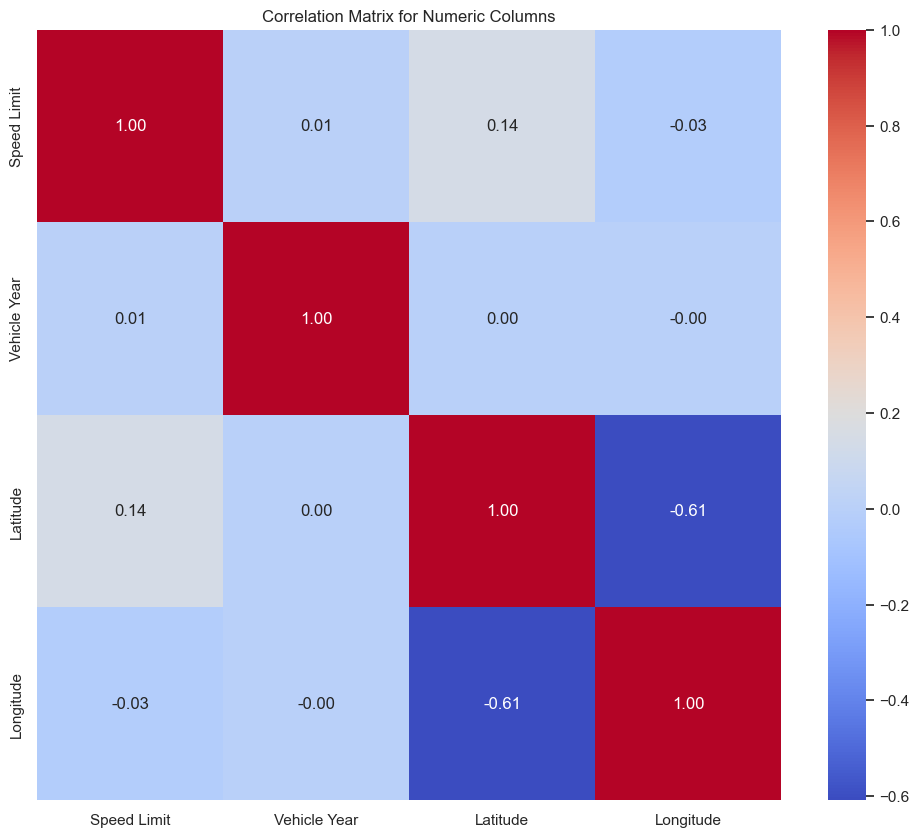

In [119]:
import seaborn as sns
import matplotlib.pyplot as plt
# Select only numeric columns
df_numeric = df.select_dtypes(include=['number'])

# Compute the correlation matrix (default is Pearson correlation)
corr_matrix = df_numeric.corr()

# Display the correlation matrix
print(corr_matrix)

# Optional: visualize with a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix for Numeric Columns')
plt.show()

                               Report Number  Local Case Number  Agency Name  \
Report Number                       1.000000           0.938470     0.291656   
Local Case Number                   0.938470           1.000000     0.280129   
Agency Name                         0.291656           0.280129     1.000000   
ACRS Report Type                   -0.035039          -0.029710    -0.021976   
Route Type                          0.406941           0.391167     0.541128   
Road Name                           0.280541           0.264663     0.293694   
Collision Type                      0.083639           0.074343     0.063309   
Weather                            -0.002877          -0.005781    -0.030288   
Surface Condition                   0.003881           0.001151    -0.010508   
Light                              -0.001901          -0.002332    -0.001027   
Traffic Control                    -0.001711          -0.002497     0.009289   
Driver Substance Abuse              0.06

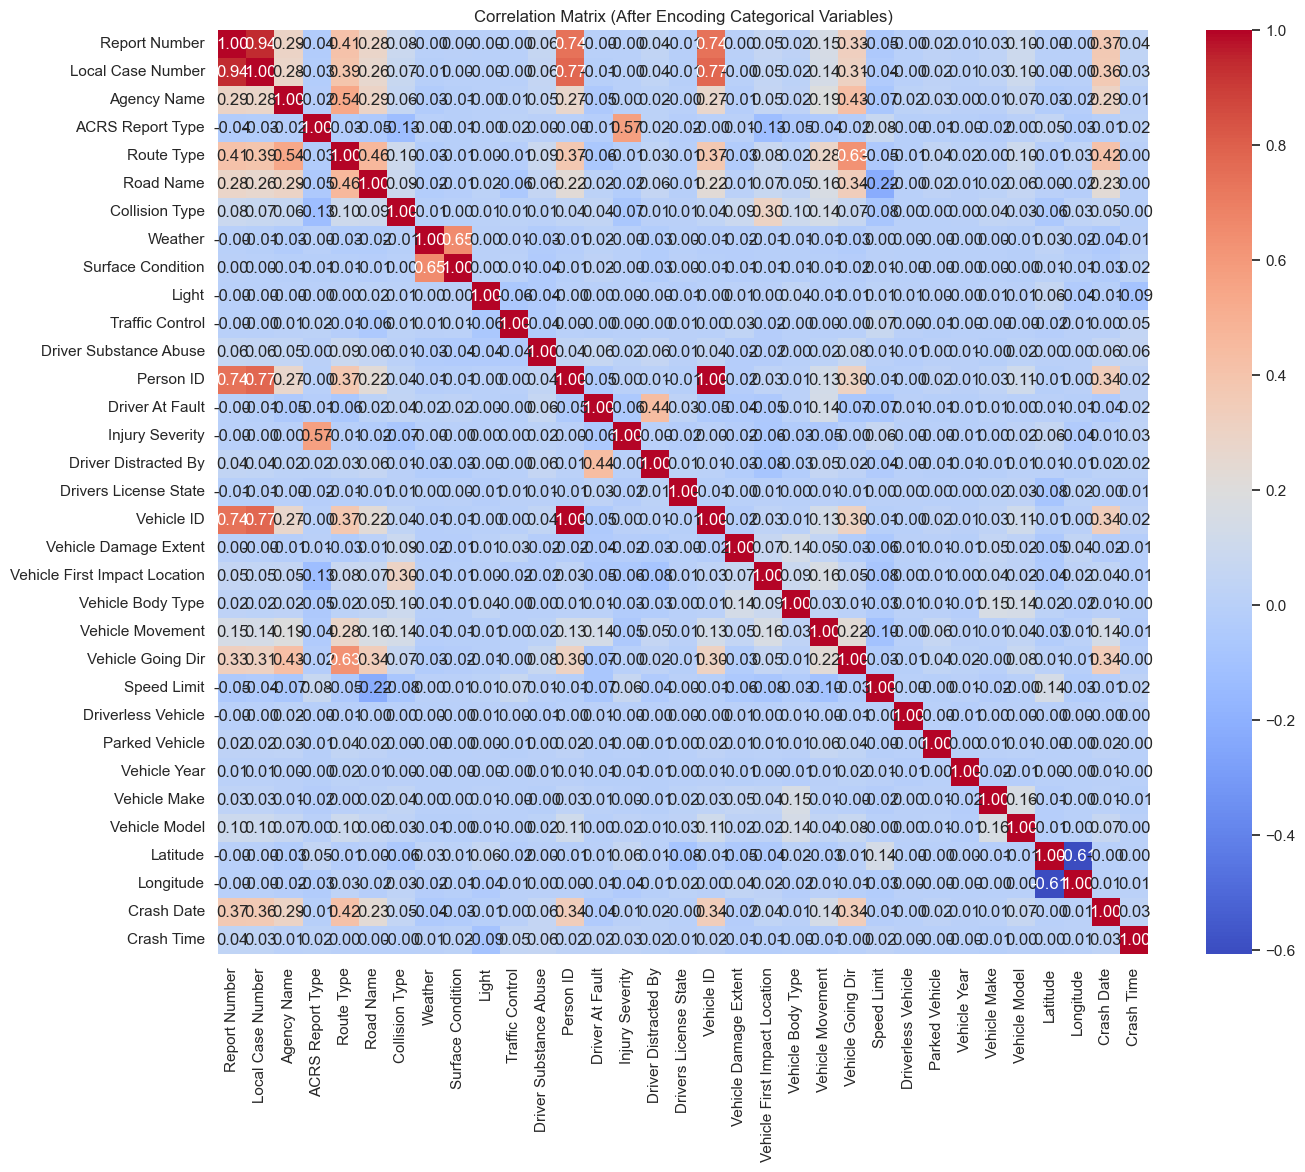

In [120]:
# Create a copy for encoding
df_encoded = df.copy()

# Convert all object (string) type columns to numeric codes
for col in df_encoded.columns:
    if df_encoded[col].dtype == 'object':
        df_encoded[col] = pd.factorize(df_encoded[col])[0]

# Now compute the correlation matrix
corr_matrix = df_encoded.corr()

# Display the matrix
print(corr_matrix)

# Visualize with a heatmap
plt.figure(figsize=(15, 12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix (After Encoding Categorical Variables)')
plt.show()

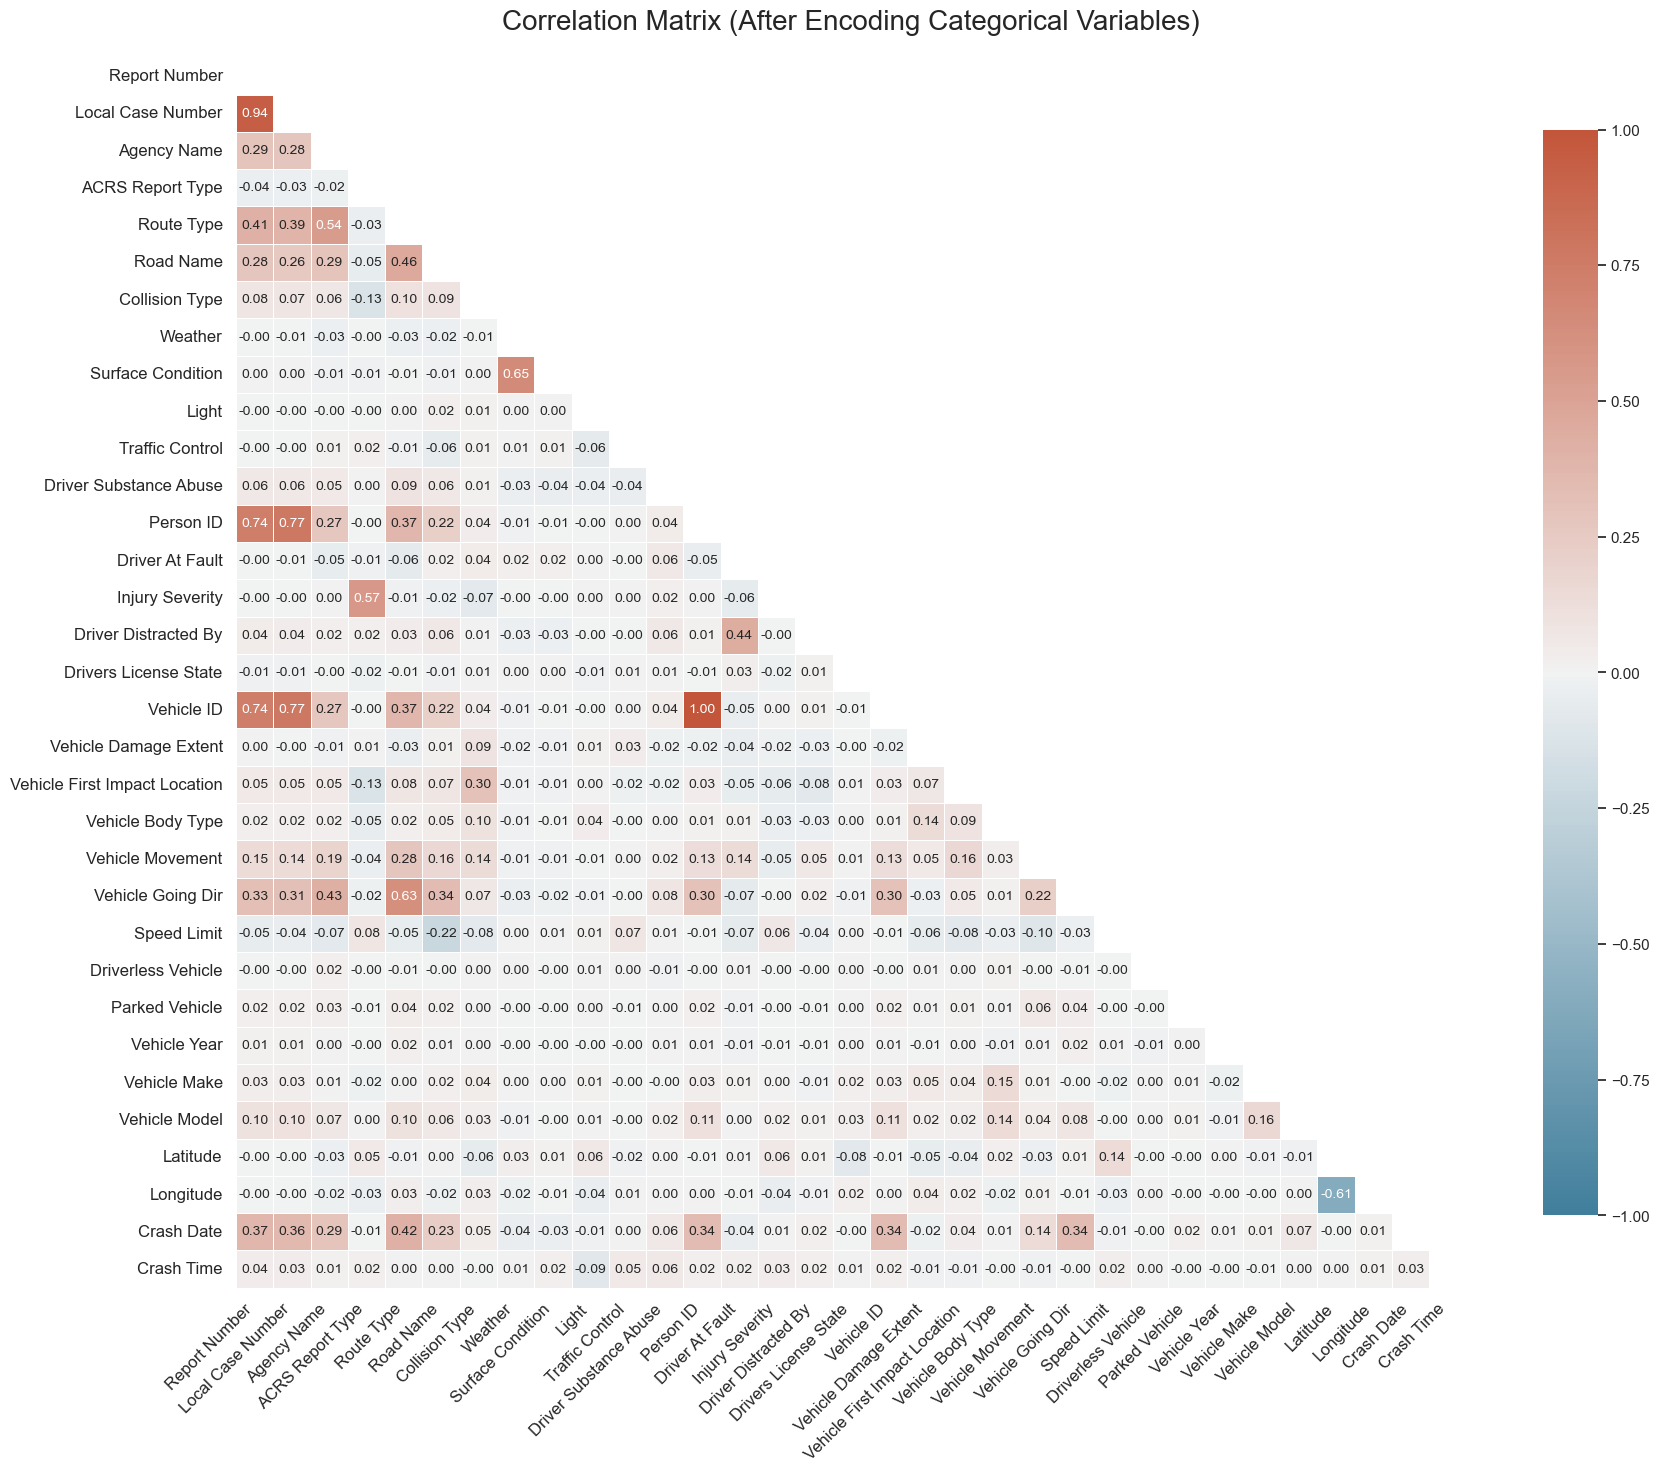

In [121]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Set a clean style
sns.set(style="white")

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Create a custom diverging colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Set up the matplotlib figure
plt.figure(figsize=(18, 16))

# Draw the heatmap with the mask and correct aspect ratio
heatmap = sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap=cmap,
    vmax=1,
    vmin=-1,
    center=0,
    annot=True,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.75},
    fmt=".2f",
    annot_kws={"size": 10}
)

# Add title and adjust labels
plt.title('Correlation Matrix (After Encoding Categorical Variables)', fontsize=20, pad=20)
plt.xticks(fontsize=12, rotation=45, ha='right')
plt.yticks(fontsize=12, rotation=0)
plt.tight_layout()

# Display the plot
plt.show()


In [122]:
# Save the figure as a JPEG file with high resolution
plt.savefig("correlation_matrix.jpg", dpi=300, format="jpg", bbox_inches='tight')

# Display the plot
plt.show()

<Figure size 640x480 with 0 Axes>

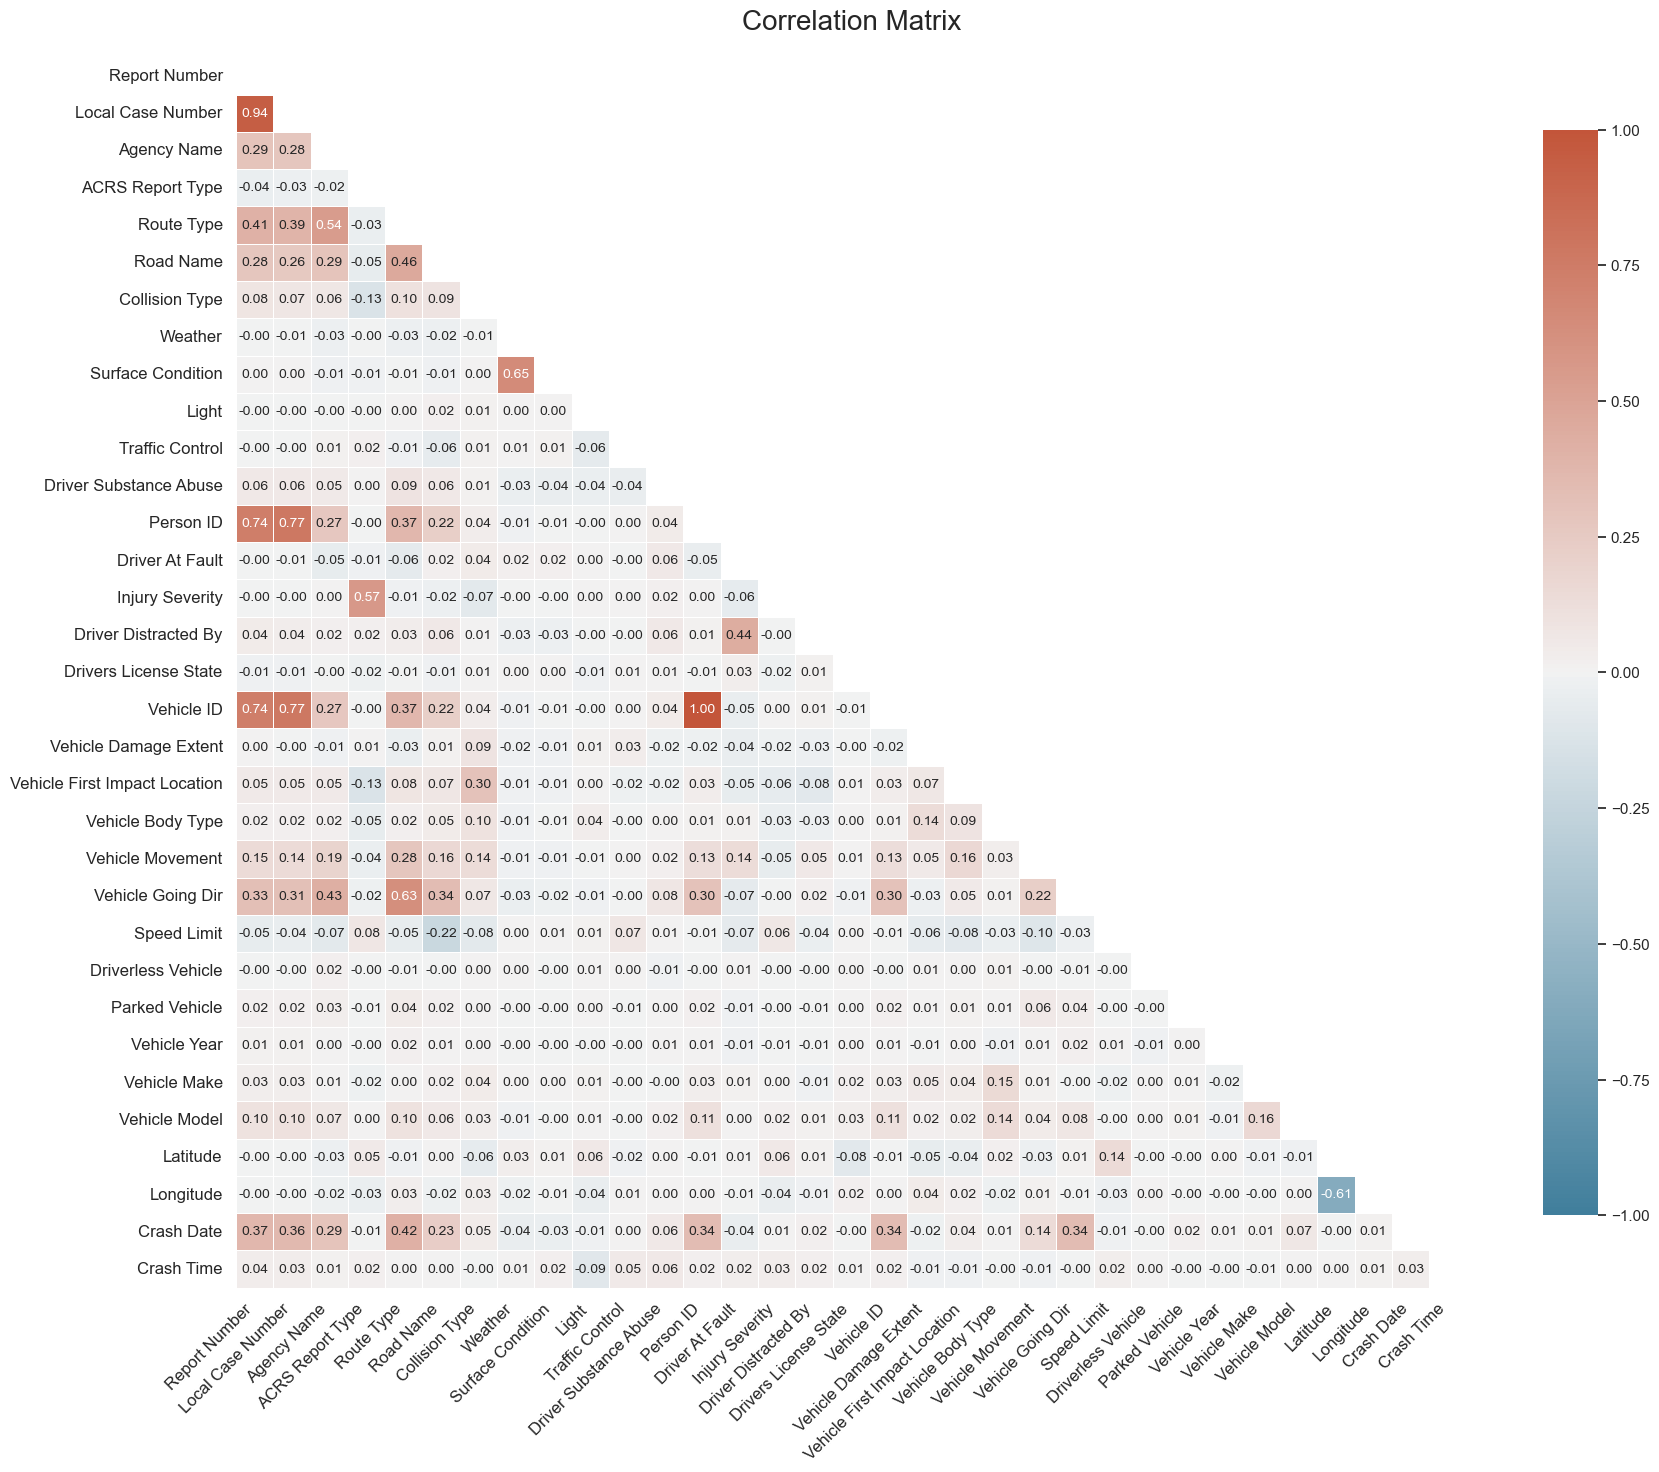

In [123]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Set a clean style
sns.set(style="white")

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Create a custom diverging colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Set up the matplotlib figure
plt.figure(figsize=(18, 16))

# Draw the heatmap with the mask and correct aspect ratio
heatmap = sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap=cmap,
    vmax=1,
    vmin=-1,
    center=0,
    annot=True,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.75},
    fmt=".2f",
    annot_kws={"size": 10}
)

# Add title and adjust labels
plt.title('Correlation Matrix', fontsize=20, pad=20)
plt.xticks(fontsize=12, rotation=45, ha='right')
plt.yticks(fontsize=12, rotation=0)
plt.tight_layout()

# Save the plot as a JPEG file with high resolution
plt.savefig("correlation_matrix.jpg", dpi=300, format="jpg", bbox_inches='tight')

# Display the plot
plt.show()


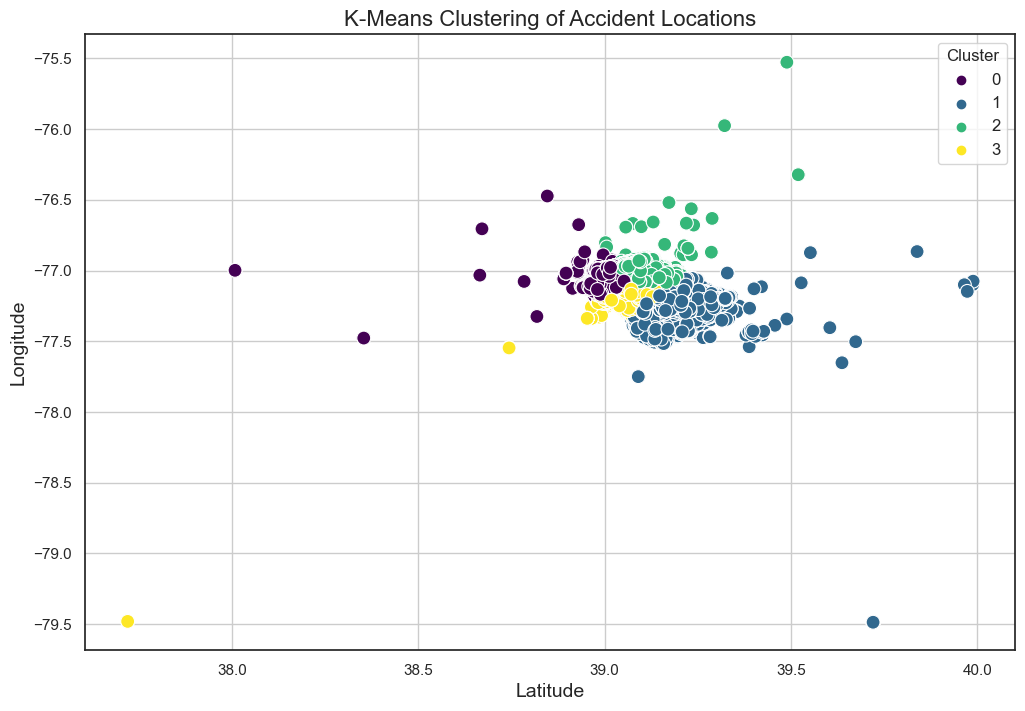

In [124]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Standardize latitude and longitude for clustering
scaler = StandardScaler()
df[['Latitude_scaled', 'Longitude_scaled']] = scaler.fit_transform(df[['Latitude', 'Longitude']])

# Perform KMeans clustering with optimal K (assumed K=4, can be adjusted)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(df[['Latitude_scaled', 'Longitude_scaled']])

# Visualizing clusters on a scatter plot
plt.figure(figsize=(12, 8))
sns.scatterplot(x=df['Latitude'], y=df['Longitude'], hue=df['Cluster'], palette='viridis', s=100)
plt.xlabel("Latitude", fontsize=14)
plt.ylabel("Longitude", fontsize=14)
plt.title("K-Means Clustering of Accident Locations", fontsize=16)
plt.legend(title='Cluster', fontsize=12)
plt.grid(True)
plt.show()

# Convert 'Injury Severity' into numerical values
severity_mapping = {
    'NO APPARENT INJURY': 0,
    'POSSIBLE INJURY': 1,
    'SUSPECTED MINOR INJURY': 2,
    'SUSPECTED SERIOUS INJURY': 3,
    'FATAL INJURY': 4
}
df['Severity Numeric'] = df['Injury Severity'].map(severity_mapping)

# Filter high-priority clusters (assuming clusters 0 and 1 are high-priority)
high_priority_clusters = [0, 1]  # Update based on previous analysis
df_high_priority = df[df['Cluster'].isin(high_priority_clusters)]

# Group by lighting condition and calculate mean severity
df_lighting = df_high_priority.groupby('Light')['Severity Numeric'].mean().reset_index()


In [125]:

# Hypothesis Testing: Does Poor Lighting Lead to More Severe Accidents?
# Group severity based on lighting conditions
well_lit = df_high_priority[df_high_priority['Light'].isin(['DAYLIGHT', 'DARK (WITH LIGHTS ON)'])]['Severity Numeric']
poorly_lit = df_high_priority[df_high_priority['Light'].isin(['DARK (NO LIGHTS)', 'UNKNOWN/OTHER'])]['Severity Numeric']

# Chi-Square Test: Checking Proportion of Severe Accidents in Poorly Lit Areas
contingency_table = pd.crosstab(df_high_priority['Light'], df_high_priority['Severity Numeric'])
chi2_stat, chi2_p_value, _, _ = stats.chi2_contingency(contingency_table)
print(f"Chi-Square Statistic: {chi2_stat}, P-value: {chi2_p_value}")


Chi-Square Statistic: 94.17476333169049, P-value: 4.22884132541701e-13


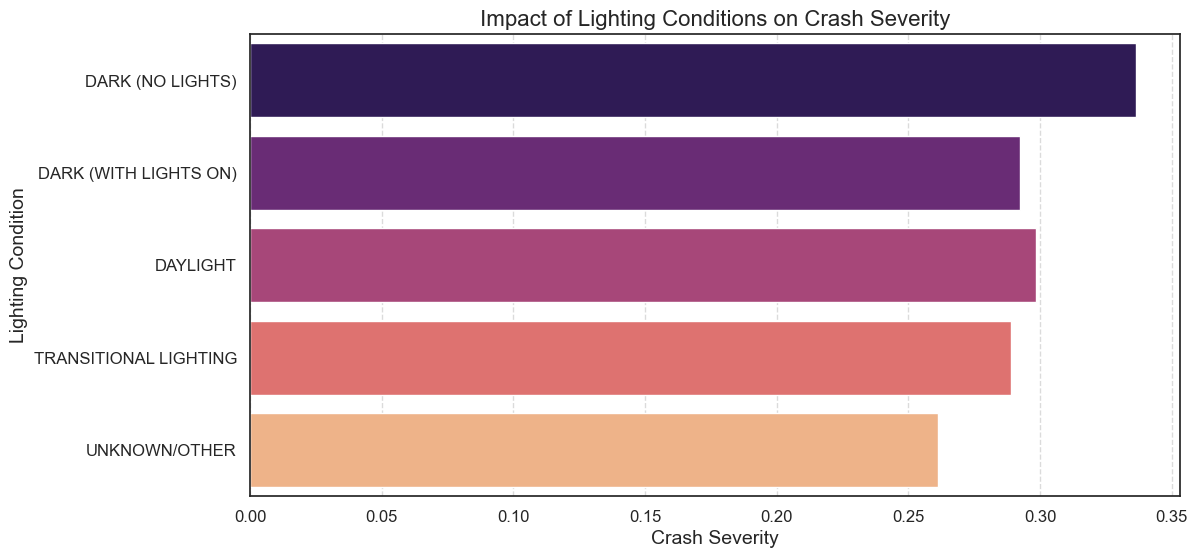

In [126]:
plt.figure(figsize=(12, 6))
sns.barplot(y='Light', x='Severity Numeric', data=df_lighting, palette='magma')
plt.xlabel("Crash Severity", fontsize=14)
plt.ylabel("Lighting Condition", fontsize=14)
plt.title("Impact of Lighting Conditions on Crash Severity", fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

Heatmap of severe crashes in poorly lit areas saved as 'heatmap_dark_no_lights.html'


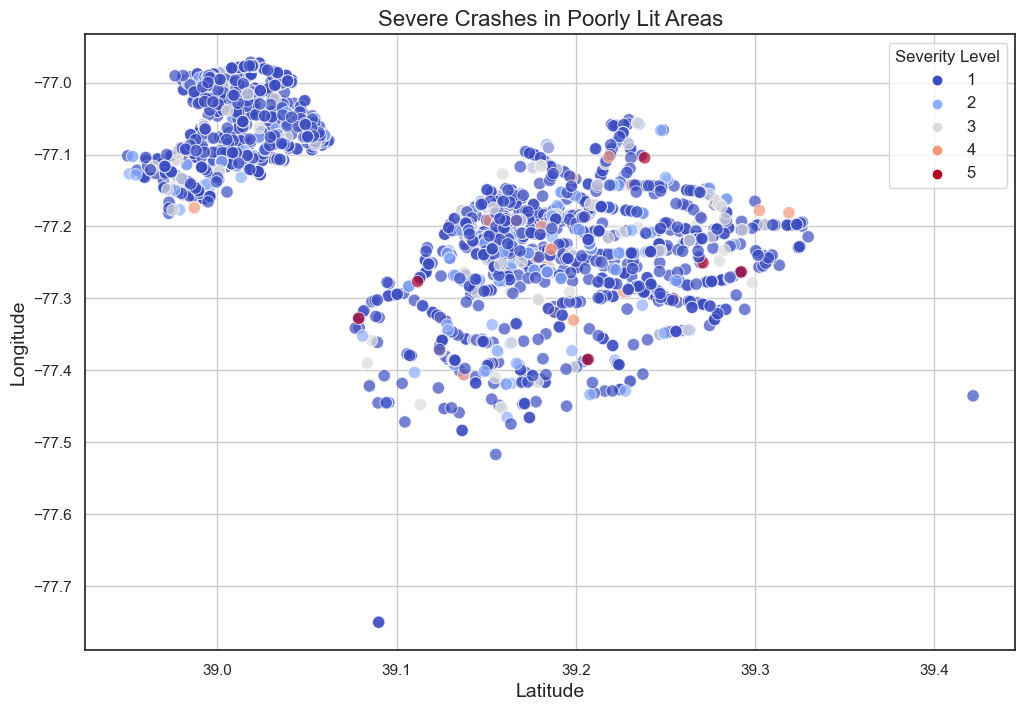

In [127]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Standardize latitude and longitude for clustering
scaler = StandardScaler()
df[['Latitude_scaled', 'Longitude_scaled']] = scaler.fit_transform(df[['Latitude', 'Longitude']])

# Perform KMeans clustering with optimal K (assumed K=4, can be adjusted)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(df[['Latitude_scaled', 'Longitude_scaled']])

# Convert 'Injury Severity' into numerical values
severity_mapping = {
    'NO APPARENT INJURY': 1,
    'POSSIBLE INJURY': 2,
    'SUSPECTED MINOR INJURY': 3,
    'SUSPECTED SERIOUS INJURY': 4,
    'FATAL INJURY': 5
}
df['Severity Numeric'] = df['Injury Severity'].map(severity_mapping)

# Filter high-priority clusters (assuming clusters 0 and 1 are high-priority)
high_priority_clusters = [0, 1]  # Update based on previous analysis
df_high_priority = df[df['Cluster'].isin(high_priority_clusters)]

# Further filter for crashes that occurred in dark conditions with no lights
df_dark_no_lights = df_high_priority[df_high_priority['Light'] == 'DARK (NO LIGHTS)']

# 1️⃣ Heatmap: Severe Crashes in Poorly Lit Areas
m = folium.Map(location=[df_dark_no_lights['Latitude'].mean(), df_dark_no_lights['Longitude'].mean()], zoom_start=12)
heat_data = list(zip(df_dark_no_lights['Latitude'], df_dark_no_lights['Longitude'], df_dark_no_lights['Severity Numeric']))
HeatMap(heat_data, radius=10).add_to(m)

# Save the heatmap as an HTML file
m.save("heatmap_dark_no_lights.html")
print("Heatmap of severe crashes in poorly lit areas saved as 'heatmap_dark_no_lights.html'")

# 2️⃣ Scatter Plot: High-Severity Crashes in Dark Conditions
plt.figure(figsize=(12, 8))
sns.scatterplot(x=df_dark_no_lights['Latitude'], y=df_dark_no_lights['Longitude'], hue=df_dark_no_lights['Severity Numeric'], palette='coolwarm', s=80, alpha=0.7)
plt.xlabel("Latitude", fontsize=14)
plt.ylabel("Longitude", fontsize=14)
plt.title("Severe Crashes in Poorly Lit Areas", fontsize=16)
plt.legend(title="Severity Level", fontsize=12)
plt.grid(True)
plt.show()

# 3️⃣ Identify High-Risk Locations (Street Names & Intersections if available)
if 'Street Name' in df.columns:
    high_risk_streets = df_dark_no_lights['Street Name'].value_counts().head(10)
    print("Top 10 High-Risk Streets for Severe Crashes in Dark Conditions:")
    print(high_risk_streets)


In [128]:
pip install folium

Note: you may need to restart the kernel to use updated packages.


Heatmap of severe crashes in poorly lit areas saved as 'heatmap_dark_no_lights.html'


/var/folders/n_/fvk81crd6fddbjh6csc8kmt80000gn/T/ipykernel_92750/1898692293.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dark_no_lights['Hotspot Cluster'] = clustering.labels_


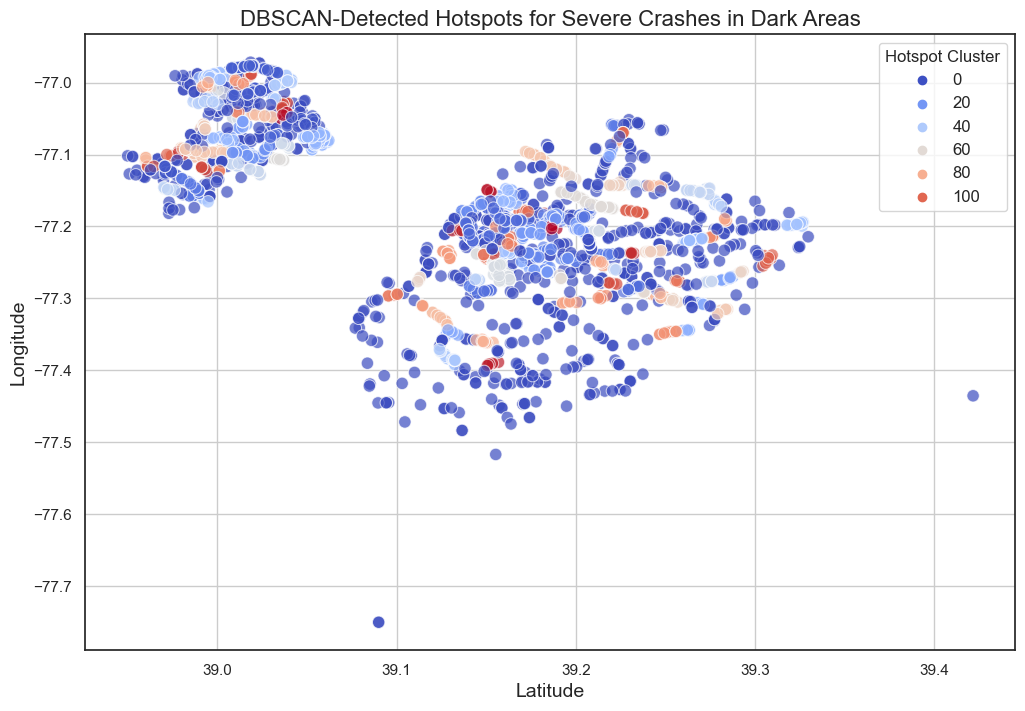

In [142]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# Standardize latitude and longitude for clustering
scaler = StandardScaler()
df[['Latitude_scaled', 'Longitude_scaled']] = scaler.fit_transform(df[['Latitude', 'Longitude']])

# Filter high-priority clusters (assuming clusters 0 and 1 are high-priority)
high_priority_clusters = [0, 1]  # Update based on previous analysis
df_high_priority = df[df['Cluster'].isin(high_priority_clusters)]

# Further filter for crashes that occurred in dark conditions with no lights
df_dark_no_lights = df_high_priority[df_high_priority['Light'] == 'DARK (NO LIGHTS)']

# 1️⃣ Extract High-Risk Streets (Top 10 most affected areas)
if 'Street Name' in df.columns:
    high_risk_streets = df_dark_no_lights['Street Name'].value_counts().head(10)
    print("Top 10 High-Risk Streets for Severe Crashes in Dark Conditions:")
    print(high_risk_streets)

# 2️⃣ DBSCAN Clustering for Hotspot Detection
clustering = DBSCAN(eps=0.05, min_samples=5).fit(df_dark_no_lights[['Latitude_scaled', 'Longitude_scaled']])
df_dark_no_lights['Hotspot Cluster'] = clustering.labels_

# 3️⃣ Heatmap: Severe Crashes in Poorly Lit Areas
m = folium.Map(location=[df_dark_no_lights['Latitude'].mean(), df_dark_no_lights['Longitude'].mean()], zoom_start=12)
heat_data = list(zip(df_dark_no_lights['Latitude'], df_dark_no_lights['Longitude'], df_dark_no_lights['Severity Numeric']))
HeatMap(heat_data, radius=10).add_to(m)

# Save the heatmap as an HTML file
m.save("heatmap_dark_no_lights.html")
print("Heatmap of severe crashes in poorly lit areas saved as 'heatmap_dark_no_lights.html'")

# 4️⃣ Scatter Plot: DBSCAN-Detected Hotspots
plt.figure(figsize=(12, 8))
sns.scatterplot(x=df_dark_no_lights['Latitude'], y=df_dark_no_lights['Longitude'], hue=df_dark_no_lights['Hotspot Cluster'], palette='coolwarm', s=80, alpha=0.7)
plt.xlabel("Latitude", fontsize=14)
plt.ylabel("Longitude", fontsize=14)
plt.title("DBSCAN-Detected Hotspots for Severe Crashes in Dark Areas", fontsize=16)
plt.legend(title="Hotspot Cluster", fontsize=12)
plt.grid(True)
plt.show()


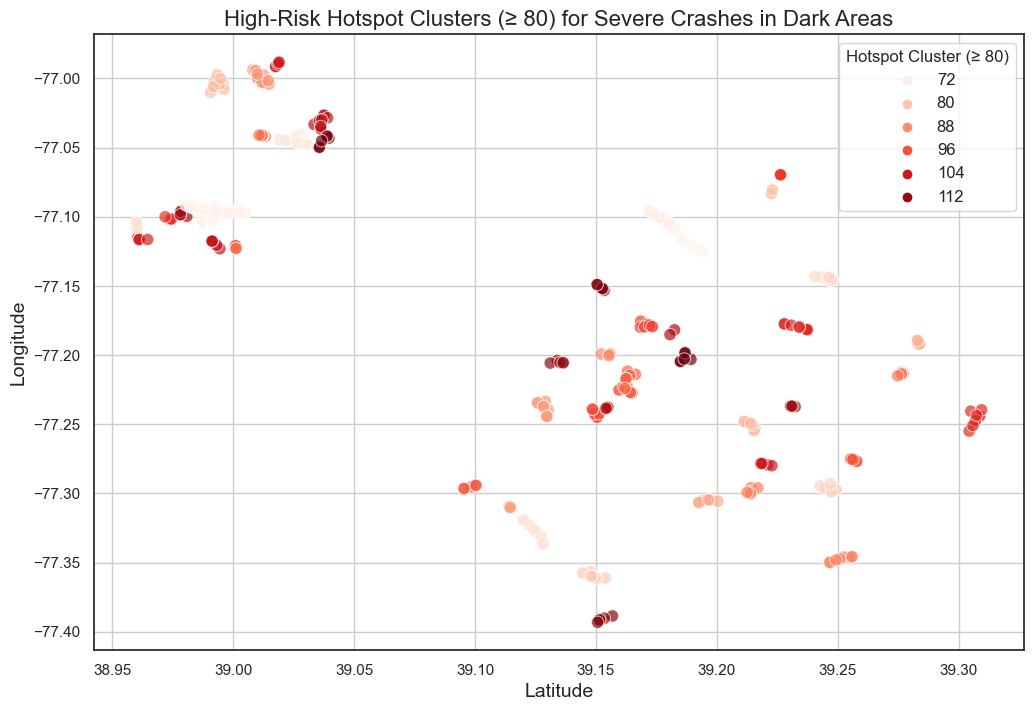

In [143]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Filter only high-risk hotspot clusters (≥ 80)
df_high_risk_hotspots = df_dark_no_lights[df_dark_no_lights['Hotspot Cluster'] >= 70]

# Scatter Plot: Only High-Risk Hotspots
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x=df_high_risk_hotspots['Latitude'], 
    y=df_high_risk_hotspots['Longitude'], 
    hue=df_high_risk_hotspots['Hotspot Cluster'], 
    palette='Reds', 
    s=80, alpha=0.7
)

plt.xlabel("Latitude", fontsize=14)
plt.ylabel("Longitude", fontsize=14)
plt.title("High-Risk Hotspot Clusters (≥ 80) for Severe Crashes in Dark Areas", fontsize=16)
plt.legend(title="Hotspot Cluster (≥ 80)", fontsize=12)
plt.grid(True)
plt.show()


KeyError: 'Hotspot Cluster'

Unique Hotspot Clusters Detected: [ 0  1 93  2  3  4  5 -1  6  7  8  9 10 88 11 12 13 14 66 15 16 19 17 18
 20 21 22 23 24 25 26 31 27 28 29 30 32 33 34 35 36 37 38 39 40 57 41 48
 42 43 44 68 45 46 47 49 50 51 52 53 54 55 56 58 59 60 61 62 63 64 65 67
 69 70 71 72 73 74 75 76 92 77 78 79 80 81 82 83 84 86 85 91 87 94 89 90]

🚦 **Top High-Risk Roads for Immediate Streetlight Installation** 🚦
                                   Road Name  Crash Count
30                              WOODFIELD RD            8
6                              CLARKSBURG RD            8
15                              LOG HOUSE RD            7
4                                 CATTAIL RD            5
8                                DAMASCUS RD            5
24                                 SENECA RD            5
10                   EISENHOWER MEMORIAL HWY            5
1                             BARNESVILLE RD            5
11                             FIELDCREST RD            4
23                       

/var/folders/n_/fvk81crd6fddbjh6csc8kmt80000gn/T/ipykernel_92750/3391528303.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dark_no_lights[['Latitude_scaled', 'Longitude_scaled']] = scaler.fit_transform(df_dark_no_lights[['Latitude', 'Longitude']])
/var/folders/n_/fvk81crd6fddbjh6csc8kmt80000gn/T/ipykernel_92750/3391528303.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dark_no_lights['Hotspot Cluster'] = dbscan.labels_


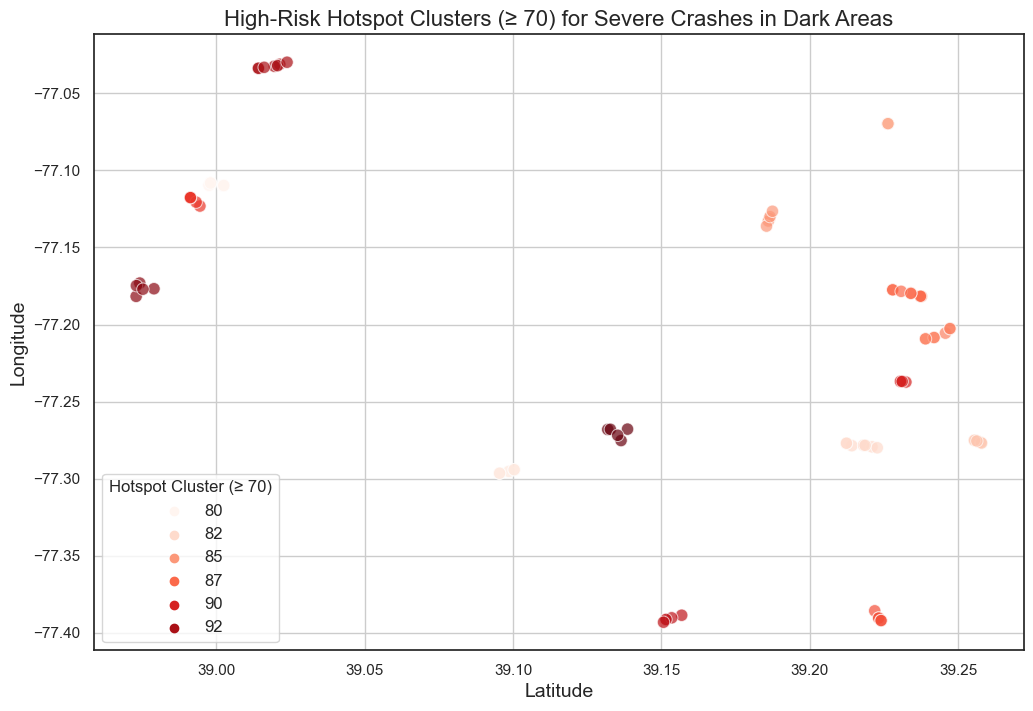

In [151]:


# Step 1: Filter dataset for high-priority clusters
high_priority_clusters = [0, 1]  
df_high_priority = df[df['Cluster'].isin(high_priority_clusters)]

# Step 2: Filter for crashes in dark conditions (without lights)
df_dark_no_lights = df_high_priority[df_high_priority['Light'] == 'DARK (NO LIGHTS)']

# Step 3: Standardize Latitude & Longitude for DBSCAN clustering
scaler = StandardScaler()
df_dark_no_lights[['Latitude_scaled', 'Longitude_scaled']] = scaler.fit_transform(df_dark_no_lights[['Latitude', 'Longitude']])

# Step 4: Apply DBSCAN clustering to detect crash hotspots
dbscan = DBSCAN(eps=0.05, min_samples=5).fit(df_dark_no_lights[['Latitude_scaled', 'Longitude_scaled']])

# Step 5: Assign the cluster labels to the dataframe
df_dark_no_lights['Hotspot Cluster'] = dbscan.labels_

# Step 6: Check unique cluster labels
print("Unique Hotspot Clusters Detected:", df_dark_no_lights['Hotspot Cluster'].unique())

# Step 7: Filter only clusters with high risk (threshold ≥ 80)
df_high_risk_hotspots = df_dark_no_lights[df_dark_no_lights['Hotspot Cluster'] >= 80]

# Step 8: Extract roads needing urgent streetlight installation
'Road Name' in df_high_risk_hotspots.columns:
    streetlight_priority_roads = (
        df_high_risk_hotspots.groupby(['Road Name'])
        .size()
        .reset_index(name='Crash Count')
        .sort_values(by='Crash Count', ascending=False)
    )
    
    # Display the top roads needing immediate intervention
    print("\n **Top High-Risk Roads for Immediate Streetlight Installation** ")
    print(streetlight_priority_roads.head(50))  
    
# 🔹 Step 9: Plot High-Risk Hotspots (≥ 80)
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x=df_high_risk_hotspots['Latitude'], 
    y=df_high_risk_hotspots['Longitude'], 
    hue=df_high_risk_hotspots['Hotspot Cluster'], 
    palette="Reds", 
    s=80, alpha=0.7
)
plt.xlabel("Latitude", fontsize=14)
plt.ylabel("Longitude", fontsize=14)
plt.title("High-Risk Hotspot Clusters (≥ 70) for Severe Crashes in Dark Areas", fontsize=16)
plt.legend(title="Hotspot Cluster (≥ 70)", fontsize=12)
plt.grid(True)
plt.show()



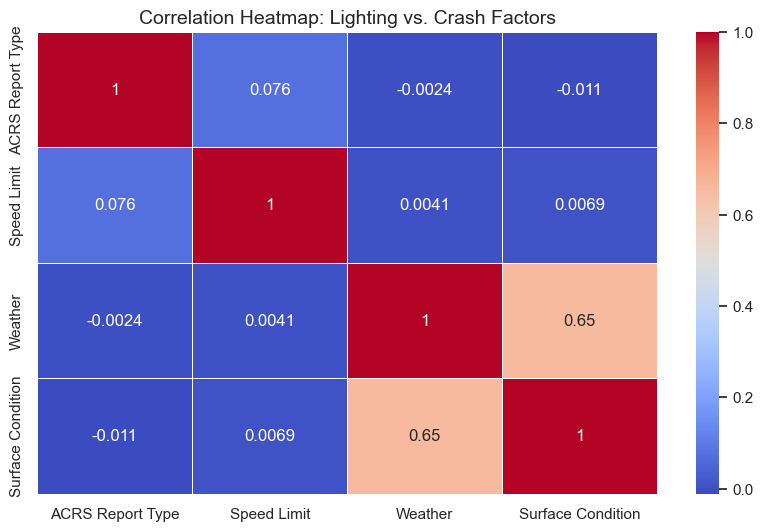

In [155]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Encode categorical variables to numeric for correlation analysis
correlation_columns = ['ACRS Report Type', 'Speed Limit', 'Weather', 'Surface Condition']
df_corr = df[correlation_columns].copy()

for col in correlation_columns:
    if df_corr[col].dtype == 'object':  # Convert categorical to numeric
        df_corr[col] = pd.factorize(df_corr[col])[0]

# Compute correlation matrix
corr_matrix = df_corr.corr()

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap: Lighting vs. Crash Factors", fontsize=14)
plt.show()


/opt/homebrew/anaconda3/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


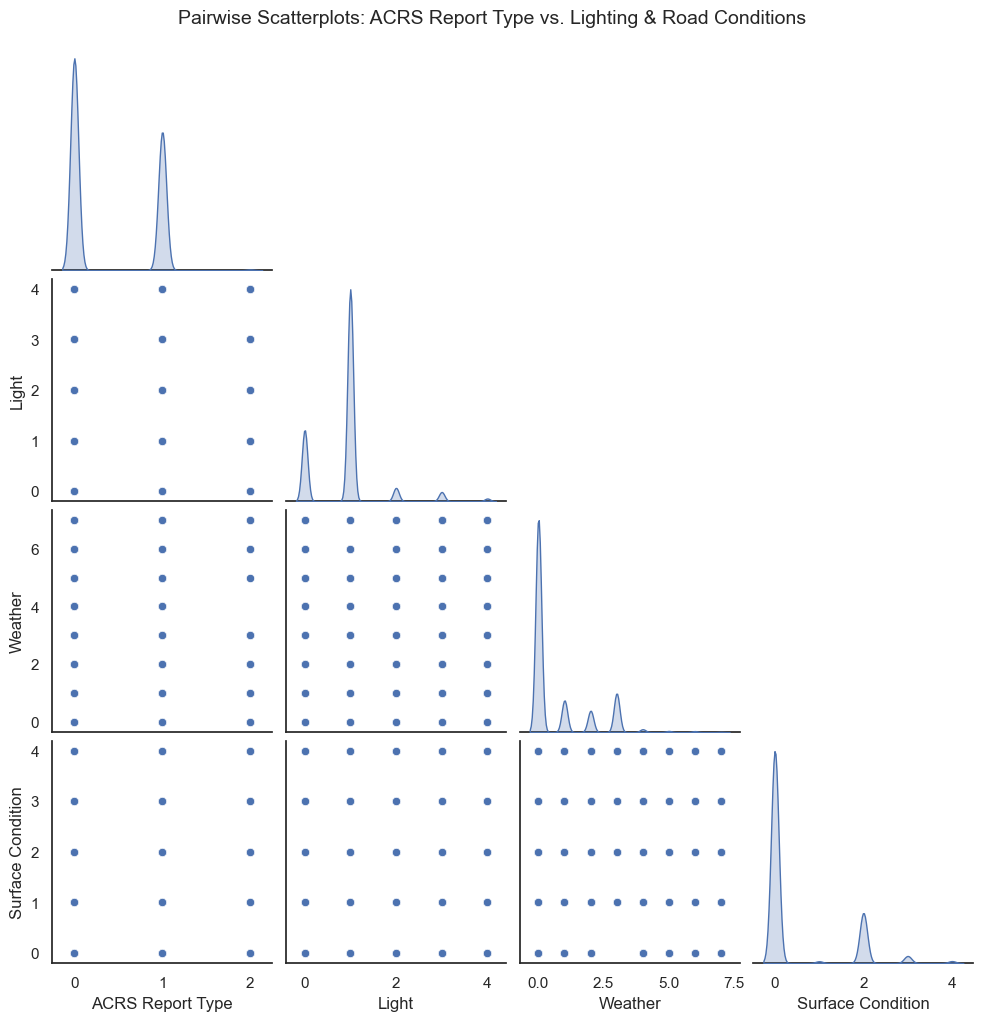

In [156]:
# Encode categorical variables for visualization
df_pairplot = df[['ACRS Report Type', 'Light', 'Weather', 'Surface Condition']].copy()
df_pairplot_encoded = df_pairplot.apply(lambda x: pd.factorize(x)[0])

# Create pairplot
sns.pairplot(df_pairplot_encoded, diag_kind='kde', corner=True)
plt.suptitle("Pairwise Scatterplots: ACRS Report Type vs. Lighting & Road Conditions", y=1.02, fontsize=14)
plt.show()


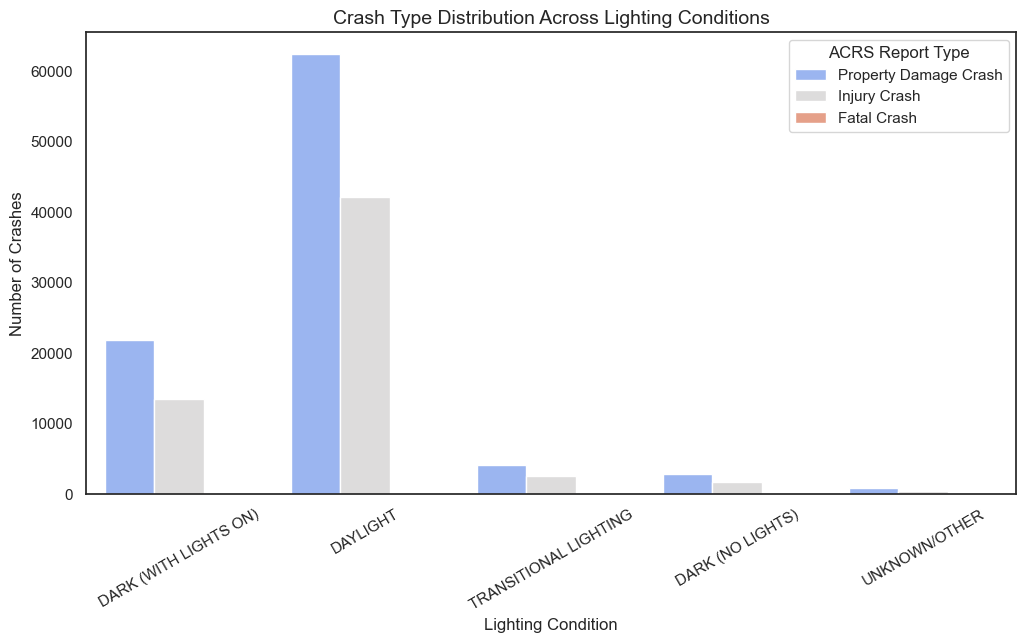

In [159]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Light', hue='ACRS Report Type', palette='coolwarm')
plt.title("Crash Type Distribution Across Lighting Conditions", fontsize=14)
plt.xlabel("Lighting Condition")
plt.ylabel("Number of Crashes")
plt.xticks(rotation=30)
plt.legend(title="ACRS Report Type")
plt.show()


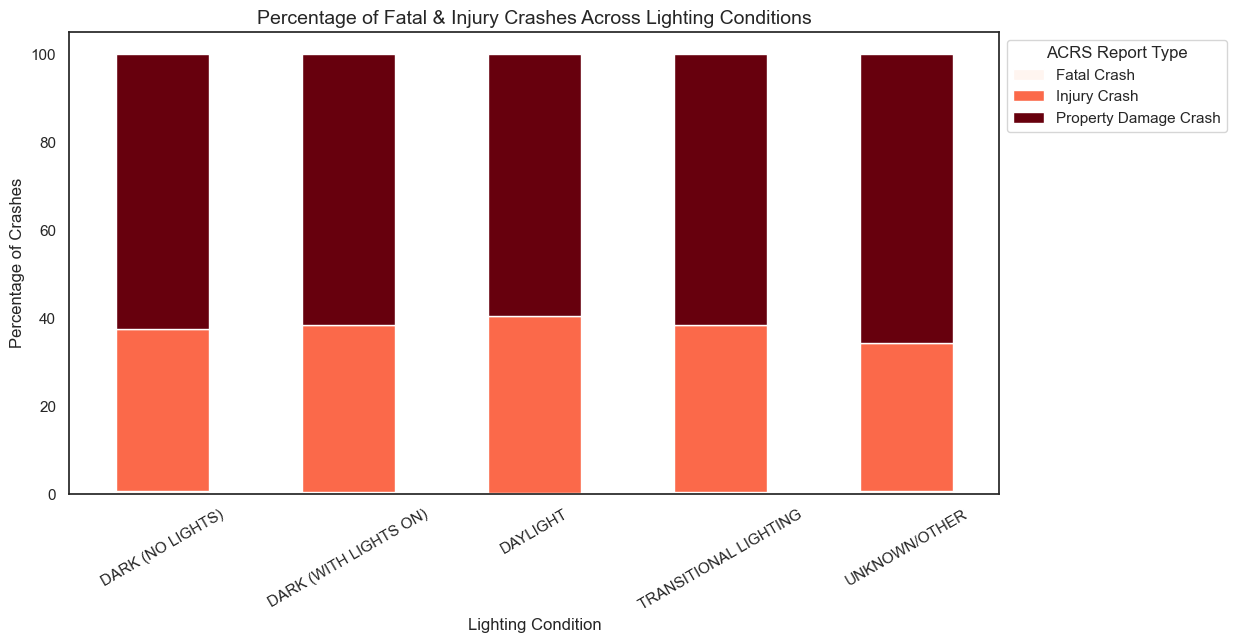

In [160]:
df_lighting = df.groupby('Light')['ACRS Report Type'].value_counts(normalize=True).unstack() * 100

df_lighting.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='Reds')
plt.title("Percentage of Fatal & Injury Crashes Across Lighting Conditions", fontsize=14)
plt.xlabel("Lighting Condition")
plt.ylabel("Percentage of Crashes")
plt.legend(title="ACRS Report Type", bbox_to_anchor=(1, 1))
plt.xticks(rotation=30)
plt.show()


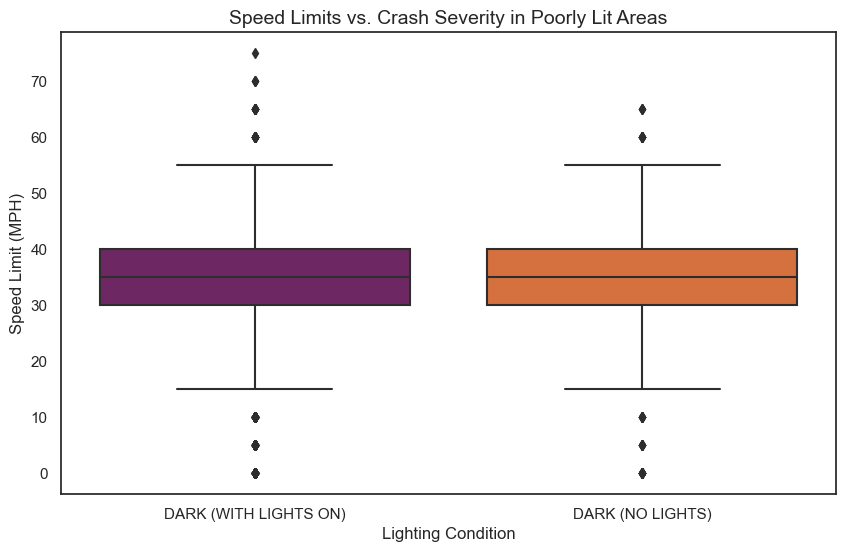

In [161]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[df['Light'].isin(['DARK (NO LIGHTS)', 'DARK (WITH LIGHTS ON)'])], 
            x='Light', y='Speed Limit', palette='inferno')
plt.title("Speed Limits vs. Crash Severity in Poorly Lit Areas", fontsize=14)
plt.xlabel("Lighting Condition")
plt.ylabel("Speed Limit (MPH)")
plt.show()


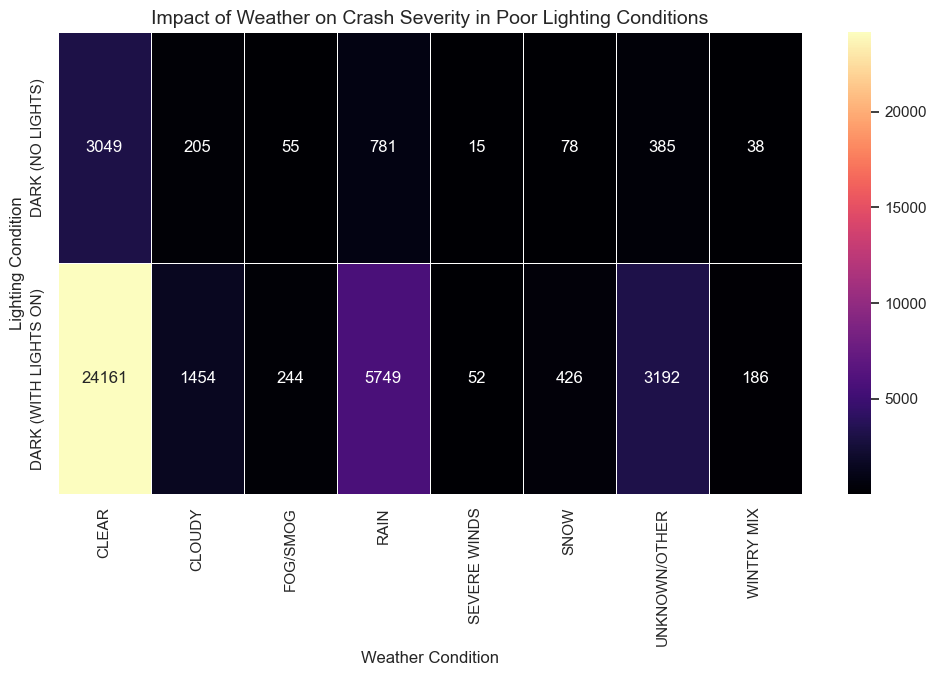

In [162]:
plt.figure(figsize=(12, 6))
df_weather_lighting = df[df['Light'].isin(['DARK (NO LIGHTS)', 'DARK (WITH LIGHTS ON)'])]\
                        .groupby(['Light', 'Weather'])['ACRS Report Type'].count().unstack()

sns.heatmap(df_weather_lighting, annot=True, fmt=".0f", cmap="magma", linewidths=0.5)
plt.title("Impact of Weather on Crash Severity in Poor Lighting Conditions", fontsize=14)
plt.xlabel("Weather Condition")
plt.ylabel("Lighting Condition")
plt.show()

